# FSS model explorer (2D Ising)

Interactive notebook for the marginal GP finite-size scaling model in
`ising/`. Edit the **configuration** cell,
run fit, and inspect posteriors and collapse plots.

Requires the dev extra: `pip install -e ".[analysis]"`

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

# Repo root on sys.path
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ising import fit, plot_posterior, simulate
from ising.constants import (
    BETA_EXACT,
    GAMMA_EXACT,
    NU_EXACT,
    OMEGA_EXACT,
    TC_EXACT,
)
from ising.datasets import get_dataset, list_datasets, resolve_paths
from ising.fit import validate_observables_df

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

/home/reuben/HMCLib/.venv/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Scaling forms

Reduced temperature $t = (T - T_c) / T_c$ and scaling variable $z = t\, L^{1/\nu}$.
Hyperscaling ($d = 2$): $\gamma = d\nu - 2\beta$.

Each observable scales as a power of $L$ times a universal function of $z$. For collapse,
multiply by the inverse power so curves at different $L$ overlay.

**Magnetization** ($m = \langle |m_{\mathrm{spin}}| \rangle$ per spin):

$$|m|(L,T) = L^{-\beta/\nu}\, \Phi_m(z), \qquad \Phi_m(z) = |m|\, L^{\beta/\nu}.$$

**Mean squared magnetization** ($\langle m^2 \rangle = \langle m_{\mathrm{spin}}^2 \rangle$ per spin):

$$\langle m^2 \rangle(L,T) = L^{-2\beta/\nu}\, \Phi_{m^2}(z), \qquad
\Phi_{m^2}(z) = \langle m^2 \rangle\, L^{2\beta/\nu}.$$

**Mean fourth power** ($\langle m^4 \rangle$ per spin):

$$\langle m^4 \rangle(L,T) = L^{-4\beta/\nu}\, \Phi_{m^4}(z), \qquad
\Phi_{m^4}(z) = \langle m^4 \rangle\, L^{4\beta/\nu}.$$

Leading correction (magnetization, $m^2$, $m^4$, & Binder channels, when `correction=True`):

$$\Phi(z, L) = f_0(z) + L^{-\omega} f_1(z), \quad \omega = 2.$$

**Binder cumulant** ($U_4 = 1 - \langle m^4\rangle / (3\langle m^2\rangle^2)$):

$$U_4(L,T) = \Phi_U(z).$$

No $L$ prefactor; same $L^{-\omega}$ correction structure as $\Phi_m$.

**Susceptibility** ($\chi = (\beta/N)\,\mathrm{Var}(M) = \beta L^d\,\mathrm{Var}(m)$ per site):

$$\chi(L,T) = L^{\gamma/\nu}\, \Phi_\chi(z), \qquad
\Phi_\chi(z) = \chi\, L^{-\gamma/\nu} = \chi\, L^{-2 + 2\beta/\nu} \quad (d=2).$$

Same $L^{-\omega}$ correction structure as $\Phi_m$ when `correction=True`.

Exact 2D values: $T_c \approx 2.269$, $\nu = 1$, $\beta = 1/8$, $\gamma = 7/4$, $\omega = 2$.

## PyMC model (`build_fss_model`)

Each active channel contributes a **marginal GP likelihood** (Harada-style) on collapsed data.

**Magnetization & Binder** (when enabled):
$$\Phi(z, L) = f_0(z) + L^{-\omega} f_1(z), \quad \omega = 2 \text{ fixed}$$
with Matérn-5/2 GPs on $f_0, f_1$ and fixed hyperparameters (stiff GP).

**Susceptibility** (when enabled):
$$\Phi_\chi(z, L) = \chi\, L^{-2 + 2\beta/\nu} = f_0(z) + L^{-\omega} f_1(z)$$
with the same fixed GP hyperparameters as the other channels. When $\chi$ is the sole
channel, GP length scales $\propto \max(z) - \min(z)$ track the inferred $\nu$.

**Priors** (defaults): $\nu \sim \mathrm{Uniform}(0.5, 1.5)$; $\beta$ and $T_c$ fixed at
exact values unless `INFER_BETA` / `INFER_TC` are enabled.

Implementation: `model_fss.py`.

In [2]:
# --- configuration (edit these) ---
# DATASET = "critical_large_z"
DATASET = "critical_fss"
MODEL = "fss"

INFER_TC = False
INFER_NU = False
INFER_BETA = True

USE_M = True
USE_M2 = True
USE_M4 = True
USE_BINDER = True
USE_CHI = False

# Per-channel L^-omega f1(z) correction (passed to fit; ignored when channel disabled).
CORRECTION_M = True
CORRECTION_M2 = True
CORRECTION_M4 = True
CORRECTION_BINDER = False
CORRECTION_CHI = False

DRAWS = 500
TUNE = 500
CHAINS = 4

REDO_SIMULATE = False
REDO_FIT = True
REDO_PLOT = True

# Collapse plots (independent of fit flags — set which panels to draw)
COLLAPSE_CHANNELS = ("m", "m2", "m4", "binder")

# Collapse plots use these exponents (defaults: exact values)
COLLAPSE_TC = TC_EXACT
COLLAPSE_NU = NU_EXACT
COLLAPSE_BETA = BETA_EXACT

In [3]:
print("Available datasets:")
for name in list_datasets():
    spec = get_dataset(name)
    print(f"  {name:16s}  {spec.n_points:3d} pts  sweeps={spec.n_sweeps:5d}  {spec.description}")

data_path, posterior_path, plots_path = resolve_paths(DATASET, model=MODEL)
print(f"\nData:      {data_path}")
print(f"Posterior: {posterior_path}")
print(f"Plots:     {plots_path}")

Available datasets:
  small              12 pts  sweeps= 2000  Smoke-test grid: 2 lattice sizes, 6 temperatures (bulk-ordered, subcritical, T_c, above T_c).
  small_long         16 pts  sweeps= 8000  Sparse grid like small plus T=2.40, 2.50 (16 points) with long chains for lower Monte Carlo noise while keeping inference cost low.
  medium             60 pts  sweeps= 4000  Default production grid: 6 lattice sizes, 10 temperatures.
  medium_short       60 pts  sweeps=  800  Same (L, T) grid as medium with n_sweeps=800 (~1/5 of medium) for noisier MC errors and wider exponent posteriors.
  medium_veryshort   60 pts  sweeps=   22  Same (L, T) grid as medium with n_sweeps=22 (~1/182 of medium) for ~10 effective magnetization samples per point.
  large             198 pts  sweeps= 8000  High-statistics grid: 9 lattice sizes, dense temperature sampling, long chains.
  critical           28 pts  sweeps=12000  Near-T_c grid for joint m + Binder FSS: 4 lattice sizes, 7 symmetric temperatures (|t

In [4]:
if REDO_SIMULATE or not data_path.exists():
    simulate.simulate_dataset(DATASET, out=data_path)
else:
    print(f"Skipping simulate ({data_path} exists)")

Skipping simulate (/home/reuben/HMCLib/ising/data/observables_critical_fss.csv exists)


,L,T,magnetization,magnetization_std,n_eff,log_magnetization,log_magnetization_std,n_eff_log,susceptibility,susceptibility_std,...,n_eff_binder,m2,m2_std,n_eff_m2,m4,m4_std,n_eff_m4,n_sweeps,n_thermalize,seed
0,64,2.2585,0.646600,0.139296,5241.518066,-0.484446,0.299572,8490.653936,1075.732099,650.870245,...,4070.593635,0.437494,0.146372,5096.441406,0.212825,0.110442,5327.433105,40000,4000,0
1,64,2.2621,0.632815,0.143773,5215.380859,-0.509679,0.303644,7869.990568,1016.377733,638.725336,...,3917.231539,0.421126,0.148693,5040.018555,0.199456,0.108907,5208.045410,40000,4000,1
2,64,2.2649,0.618800,0.152171,5223.258789,-0.542622,0.345240,8780.976779,955.836649,634.694735,...,3739.667526,0.406068,0.153695,4965.654297,0.188513,0.109130,5050.253906,40000,4000,2
3,64,2.2671,0.613584,0.153296,5314.720215,-0.553135,0.349461,7862.558747,937.000762,624.446411,...,3688.387766,0.399984,0.153444,5141.410645,0.183532,0.107833,5333.366699,40000,4000,3
4,64,2.2681,0.602593,0.159300,4431.423340,-0.579084,0.358492,6942.243203,905.031575,621.745506,...,3293.555127,0.388494,0.157197,4368.256836,0.175637,0.108128,4650.291016,40000,4000,4


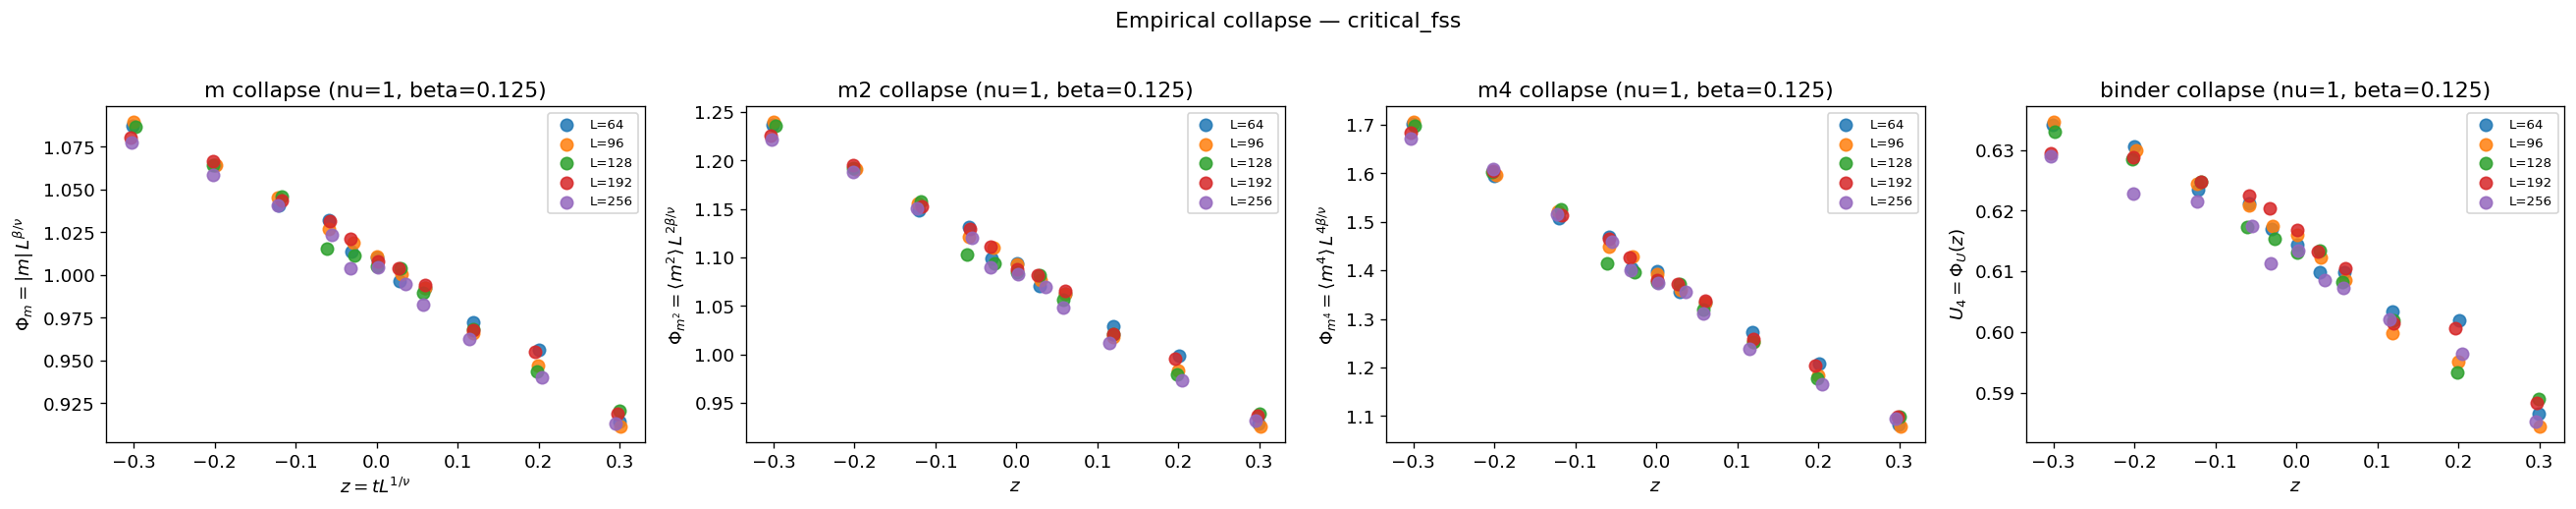

In [5]:
def empirical_collapse(
    df: pd.DataFrame,
    *,
    T_c: float,
    nu: float,
    beta: float,
    channels: tuple[str, ...] = ("m", "m2", "m4", "binder", "chi"),
) -> None:
    """Quick collapse diagnostic at fixed exponents (no GP)."""
    L = df["L"].to_numpy(dtype=float)
    T = df["T"].to_numpy(dtype=float)
    t = (T - T_c) / T_c
    z = t * L ** (1.0 / nu)

    specs: list[tuple[str, np.ndarray, str, str]] = []
    if "m" in channels:
        phi_m = df["magnetization"].to_numpy(float) * L ** (beta / nu)
        specs.append(("m", phi_m, r"$z = t L^{1/\nu}$", r"$\Phi_m = |m|\, L^{\beta/\nu}$"))
    if "m2" in channels:
        phi_m2 = df["m2"].to_numpy(float) * L ** (2.0 * beta / nu)
        specs.append(
            ("m2", phi_m2, r"$z$", r"$\Phi_{m^2} = \langle m^2 \rangle\, L^{2\beta/\nu}$")
        )
    if "m4" in channels:
        phi_m4 = df["m4"].to_numpy(float) * L ** (4.0 * beta / nu)
        specs.append(
            ("m4", phi_m4, r"$z$", r"$\Phi_{m^4} = \langle m^4 \rangle\, L^{4\beta/\nu}$")
        )
    if "binder" in channels:
        specs.append(("binder", df["binder_cumulant"].to_numpy(float), r"$z$", r"$U_4 = \Phi_U(z)$"))
    if "chi" in channels:
        scale = L ** (-2.0 + 2.0 * beta / nu)
        phi = df["susceptibility"].to_numpy(float) * scale
        specs.append(("chi", phi, r"$z$", r"$\Phi_\chi = \chi\, L^{-2 + 2\beta/\nu}$"))

    if not specs:
        raise ValueError("No collapse channels selected")

    n = len(specs)
    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.2), squeeze=False)
    for ax, (name, y, xlabel, ylabel) in zip(axes[0], specs):
        for Lval in sorted(df["L"].unique()):
            mask = df["L"] == Lval
            ax.scatter(z[mask], y[mask], label=f"L={int(Lval)}", s=55, alpha=0.85)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name} collapse (nu={nu:.3g}, beta={beta:.3g})")
        ax.legend(fontsize=8)
    fig.suptitle(f"Empirical collapse — {DATASET}", y=1.02)
    fig.tight_layout()
    plt.show()


if data_path.exists():
    df_preview = pd.read_csv(data_path)
    validate_observables_df(df_preview)
    display(df_preview.head())
    active = COLLAPSE_CHANNELS
    empirical_collapse(
        df_preview,
        T_c=COLLAPSE_TC,
        nu=COLLAPSE_NU,
        beta=COLLAPSE_BETA,
        channels=active,
    )
else:
    print(f"No data at {data_path}. Set REDO_SIMULATE=True or run simulate.")

## Classical FSS (Binder crossings + log-log)

Independent of the marginal GP model. Estimates:

1. **$T_c$** from pairwise Binder-cumulant crossings $U_4(L, T)$.
2. **$\nu$** from the size dependence of crossing temperatures, $T_{\mathrm{cross}} - T_c \sim L^{-1/\nu}$.
3. **$\beta/\nu$** from $|m| \sim L^{-\beta/\nu}$ at $T \approx T_c$ (log-log regression).
4. **$\beta = (\beta/\nu)\cdot\nu$** once $\nu$ is known.

At the inferred exponents we collapse $|m|$ vs $z$ and overlay a **single** smooth $\Phi_m(z)$ curve: points at the same $z$-grid location (different $L$) are averaged first, then a penalized spline is fit through those cluster centres.

Traditional FSS analysis ('critical_fss')
  Binder crossings (10 pairs):
    L=64 vs L=96: T_cross=2.270358
    L=64 vs L=128: T_cross=2.268526
    L=64 vs L=192: T_cross=2.269618
    L=64 vs L=256: T_cross=2.268768
    L=96 vs L=128: T_cross=2.267536
    L=96 vs L=192: T_cross=2.269308
    L=96 vs L=256: T_cross=2.268713
    L=128 vs L=192: T_cross=2.269502
    L=128 vs L=256: T_cross=2.268779
    L=192 vs L=256: T_cross=2.266511
  T_c (mean crossing) = 2.268762 ± 0.000346  (exact 2.269185)
  ν (Binder shift)    = 1.60037 ± 8.63355  (exact 1.00000)
  β/ν (|m| vs L)      = 0.11720 ± 0.00403  (exact 0.12500)
  β = (β/ν)·ν        = 0.18756 ± 1.01184  (exact 0.12500)
  γ/ν (χ vs L)        = 1.63760 ± 0.00372  (exact 1.75000)
  hyperscaling check: γ/ν - (d - 2β/ν) = -0.12801  (d=2)


Wrote /home/reuben/HMCLib/ising/plots/critical_fss/traditional_scaling/traditional_binder_crossings.png
Wrote /home/reuben/HMCLib/ising/plots/critical_fss/traditional_scaling/traditional_magnetization_loglog.png
Wrote /home/reuben/HMCLib/ising/plots/critical_fss/traditional_scaling/traditional_susceptibility_loglog.png
Wrote /home/reuben/HMCLib/ising/plots/critical_fss/traditional_scaling/traditional_binder_shift.png
Wrote /home/reuben/HMCLib/ising/plots/critical_fss/traditional_scaling/traditional_scaling_function_fit.png
Wrote /home/reuben/HMCLib/ising/plots/critical_fss/traditional_scaling/traditional_scaling_function_exact.png
Traditional FSS analysis ('critical_fss')
  Binder crossings (10 pairs):
    L=64 vs L=96: T_cross=2.270358
    L=64 vs L=128: T_cross=2.268526
    L=64 vs L=192: T_cross=2.269618
    L=64 vs L=256: T_cross=2.268768
    L=96 vs L=128: T_cross=2.267536
    L=96 vs L=192: T_cross=2.269308
    L=96 vs L=256: T_cross=2.268713
    L=128 vs L=192: T_cross=2.269502


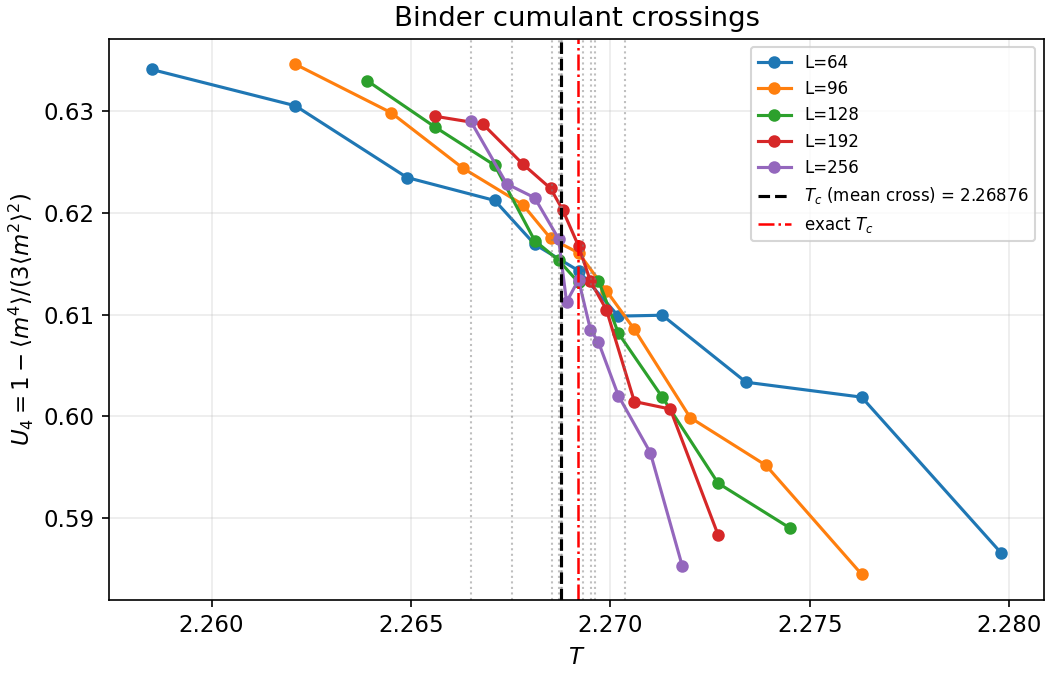

traditional_magnetization_loglog.png


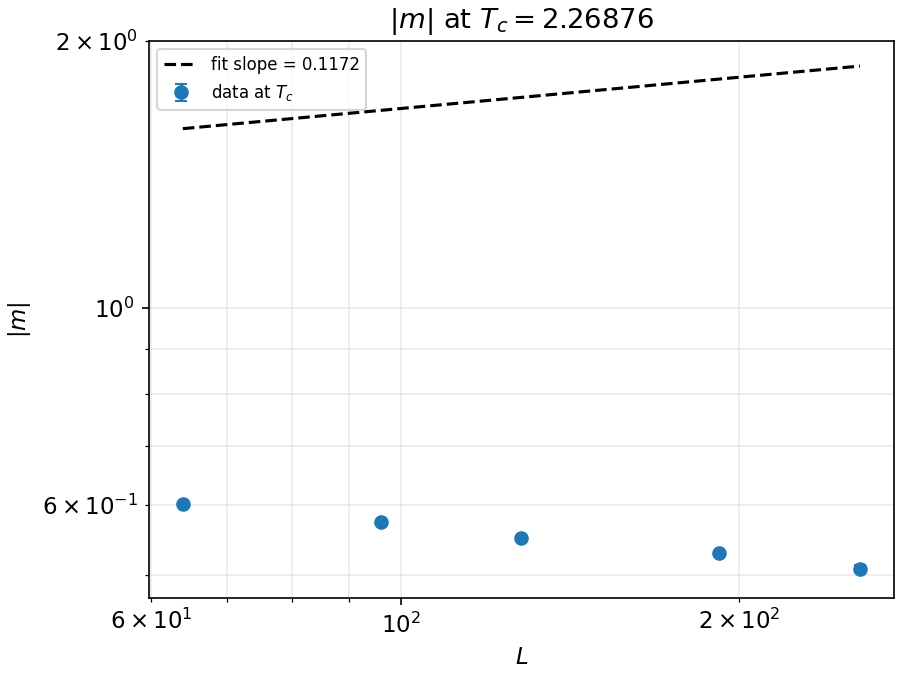

traditional_susceptibility_loglog.png


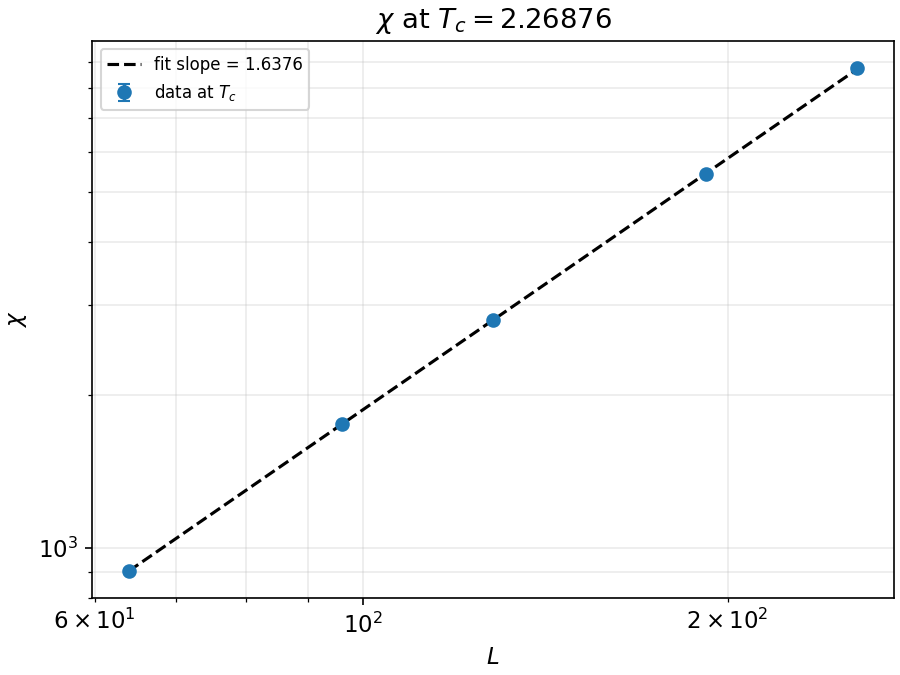

traditional_binder_shift.png


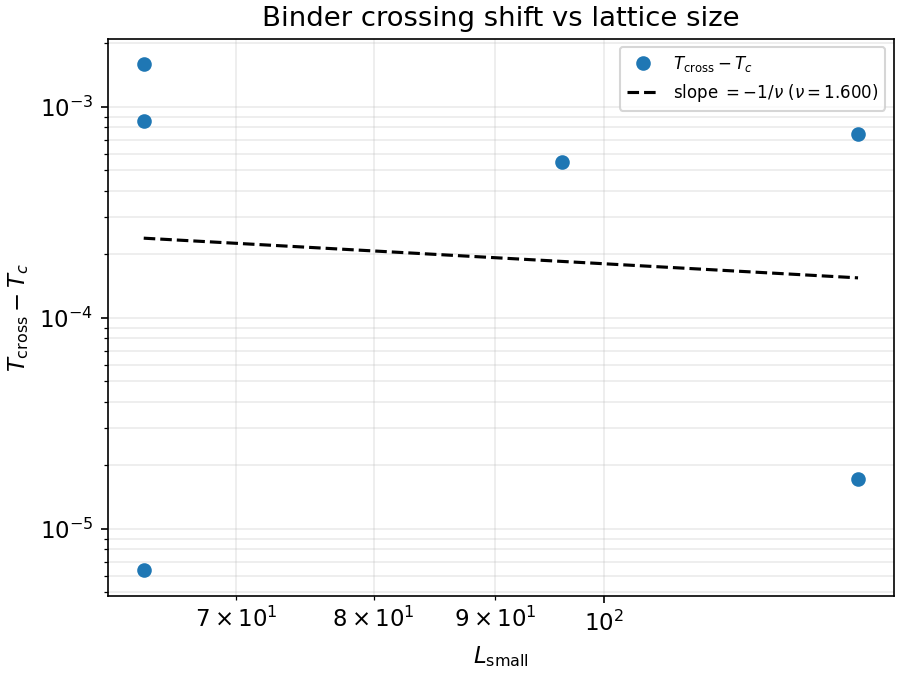

traditional_scaling_function_fit.png


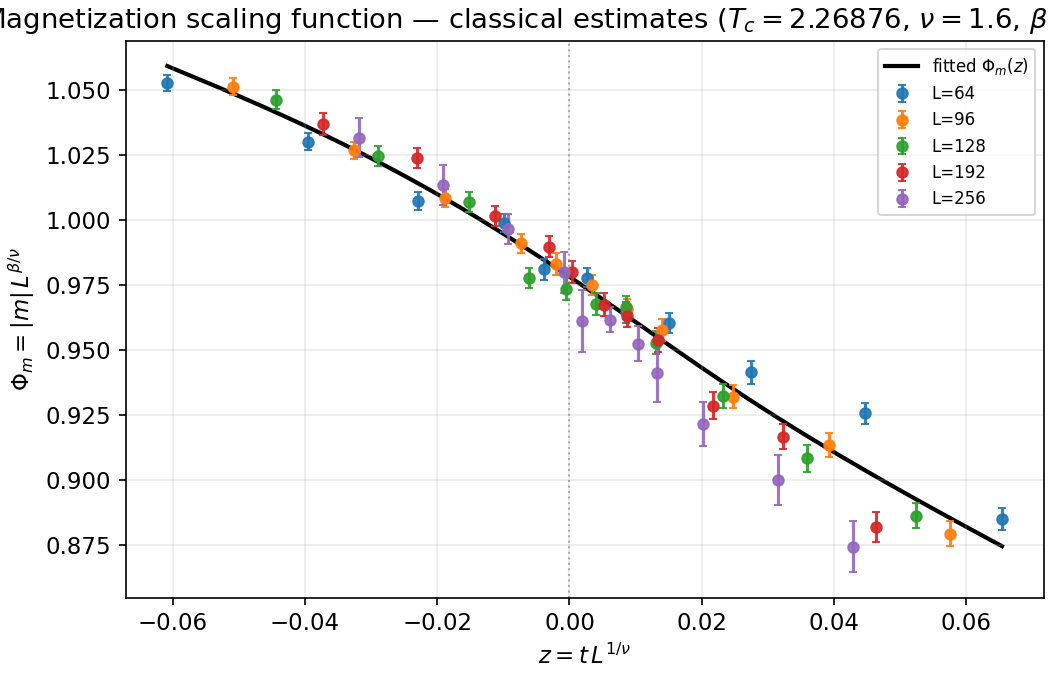

traditional_scaling_function_exact.png


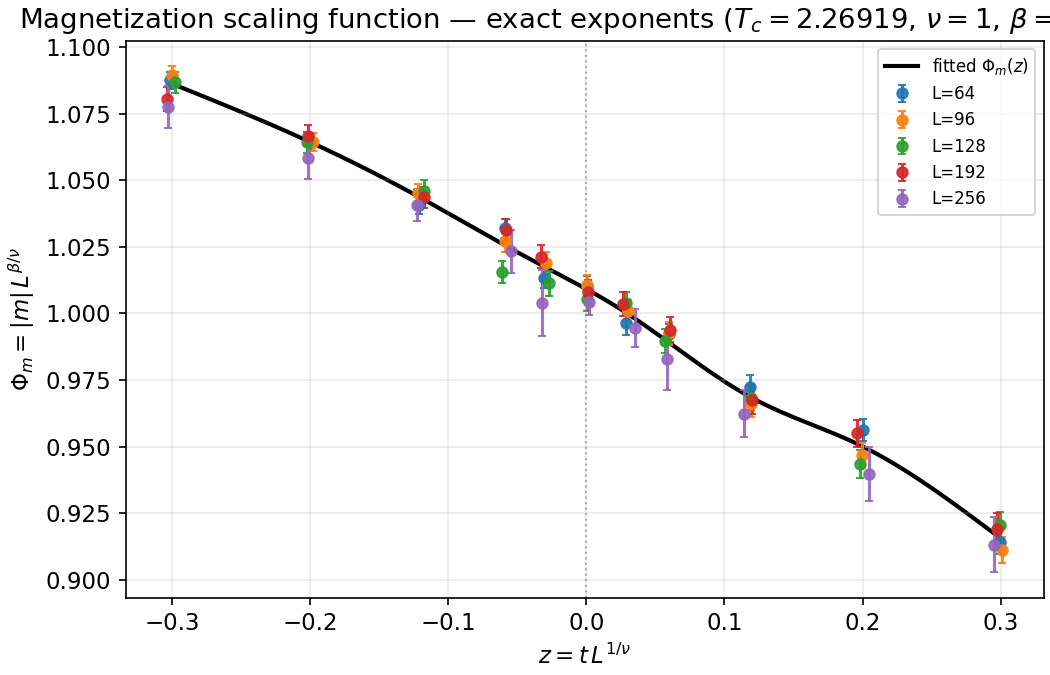

In [6]:
from ising.traditional_scaling import (
    fit_single_scaling_function_spline,
    format_traditional_scaling_summary,
    magnetization_collapse_arrays,
    run_traditional_scaling_diagnostics,
)

traditional_out = plots_path / "traditional_scaling"
traditional_result, traditional_plot_paths = run_traditional_scaling_diagnostics(
    DATASET,
    data=data_path,
    out=traditional_out,
)
print(format_traditional_scaling_summary(traditional_result))
print()
print(
    "Classical exponents for collapse comparison:",
    f"T_c={traditional_result.T_c_binder:.6f},",
    f"nu={traditional_result.nu_from_binder:.5f},",
    f"beta={traditional_result.beta:.5f}",
)

for path in traditional_plot_paths:
    print(path.name)
    display(Image(filename=path))

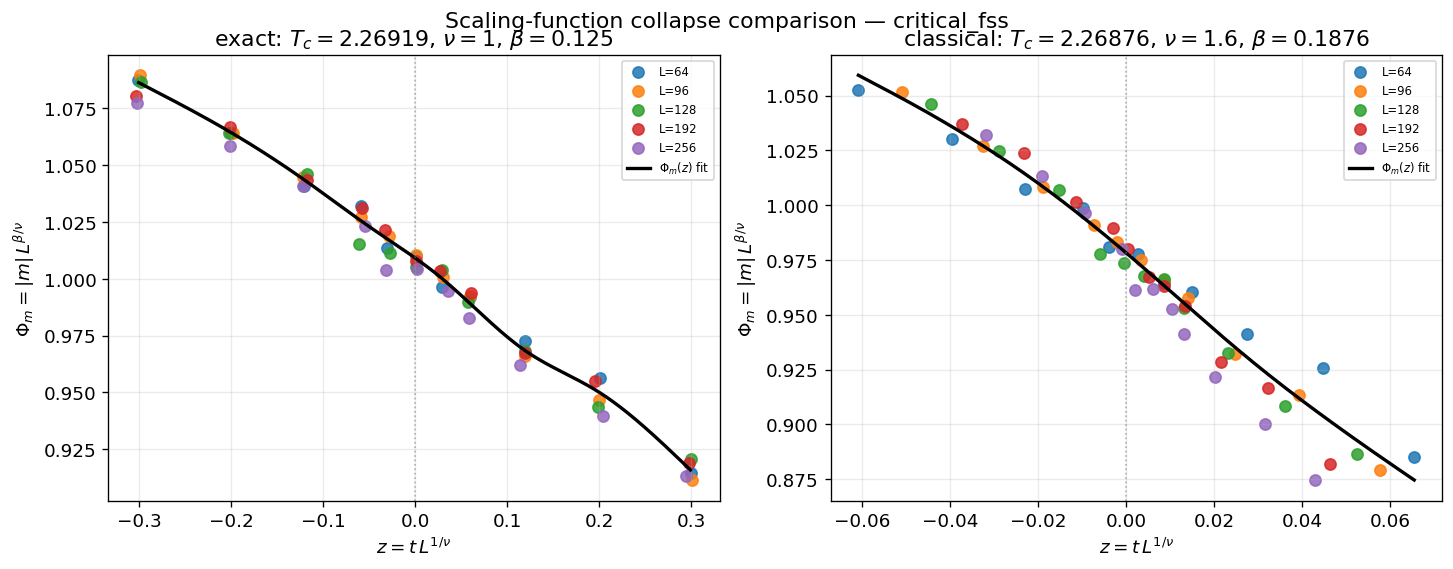

In [7]:
# Side-by-side collapse: exact exponents vs classical Binder/log-log estimates
if data_path.exists():
    df_classical = pd.read_csv(data_path)
    validate_observables_df(df_classical)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    for ax, (label, T_c, nu, beta) in zip(
        axes,
        (
            ("exact", TC_EXACT, NU_EXACT, BETA_EXACT),
            (
                "classical",
                traditional_result.T_c_binder,
                traditional_result.nu_from_binder,
                traditional_result.beta,
            ),
        ),
    ):
        z, phi, sigma_phi, L = magnetization_collapse_arrays(
            df_classical, T_c, nu, beta
        )
        z_line, phi_line = fit_single_scaling_function_spline(z, phi, sigma_phi)
        for Lval in sorted(int(v) for v in np.unique(L)):
            mask = L == Lval
            ax.scatter(z[mask], phi[mask], s=45, alpha=0.85, label=f"L={Lval}")
        ax.plot(z_line, phi_line, color="black", linewidth=2.0, label=r"$\Phi_m(z)$ fit")
        ax.axvline(0.0, color="gray", linestyle=":", linewidth=1.0, alpha=0.6)
        ax.set_xlabel(r"$z = t\, L^{1/\nu}$")
        ax.set_ylabel(r"$\Phi_m = |m|\, L^{\beta/\nu}$")
        ax.set_title(
            rf"{label}: $T_c={T_c:.5f}$, $\nu={nu:.4g}$, $\beta={beta:.4g}$"
        )
        ax.legend(fontsize=7, loc="best")
        ax.grid(True, alpha=0.25)
    fig.suptitle(f"Scaling-function collapse comparison — {DATASET}", y=1.02)
    plt.show()
else:
    print("Run the data preview cell first.")

## Collapse $\chi^2$ estimate of $\nu$ (fixed $T_c$, $\beta$)

When $T_c$ and $\beta$ are known, finite-size scaling predicts that the **collapsed**
observables
$$\Phi_m = |m|\, L^{\beta/\nu}, \quad \Phi_{m^2} = \langle m^2\rangle\, L^{2\beta/\nu}, \quad \ldots$$
depend only on the scaling variable $z = t\, L^{1/\nu}$ with $t=(T-T_c)/T_c$, not on $L$
separately. At the correct $\nu$, all lattice sizes measured at the **same** $z$ should
land on one universal value of each $\Phi$.

**Procedure (binned collapse $\chi^2$):**

1. Fix $T_c = T_{c,\mathrm{exact}}$ and $\beta = \beta_{\mathrm{exact}}$.
2. For each trial $\nu$, compute $\Phi_i$ and MC standard errors $\sigma_i$ at every
   data point $(L_i, T_i)$.
3. **Group** points that share the same target $z$ (for `z_values` grids:
   `seed % n_z`; for Cartesian grids: same temperature).
4. Within group $g$, form the weighted mean $\bar\Phi_g$ and accumulate
   $$\chi^2(\nu) = \sum_g \sum_{i\in g} \frac{(\Phi_i - \bar\Phi_g)^2}{\sigma_i^2}.$$
5. The **MLE** $\hat\nu$ minimizes $\chi^2(\nu)$. Local **curvature** of the profile
   (slope of $\Delta\chi^2 = \chi^2(\nu)-\chi^2_{\min}$ near the minimum) gives a
   1$\sigma$ uncertainty via $\Delta\chi^2=1$.

This uses every $(L, T)$ point and its error bar — not Binder crossings. A steep
$\Delta\chi^2$ profile (large $|\mathrm d\Delta\chi^2/\mathrm d\nu|$ near $\hat\nu$)
means the data sharply constrain $\nu$.

Collapse χ² ν estimate (critical_fss)
  Channels: m, m2, m4
  Fixed: T_c = 2.269185, β = 0.125
  ν̂ = 0.99123 ± 0.00424  (curvature, Δχ²=1)
  exact ν = 1  →  2.07σ from ν̂
  χ²_min = 105.4,  χ²(ν=1) = 109.6,
  Δχ²(exact) = 4.2  on 132 dof


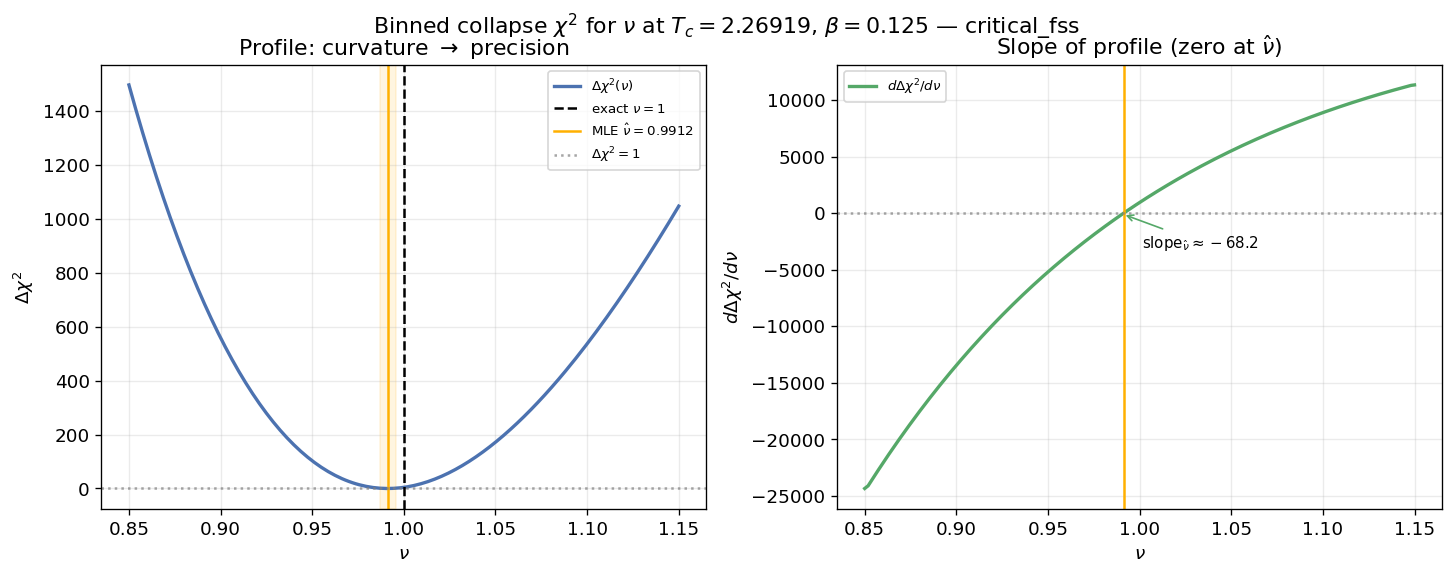

Wrote /home/reuben/HMCLib/ising/plots/critical_fss/collapse_nu_chi2_profile.png


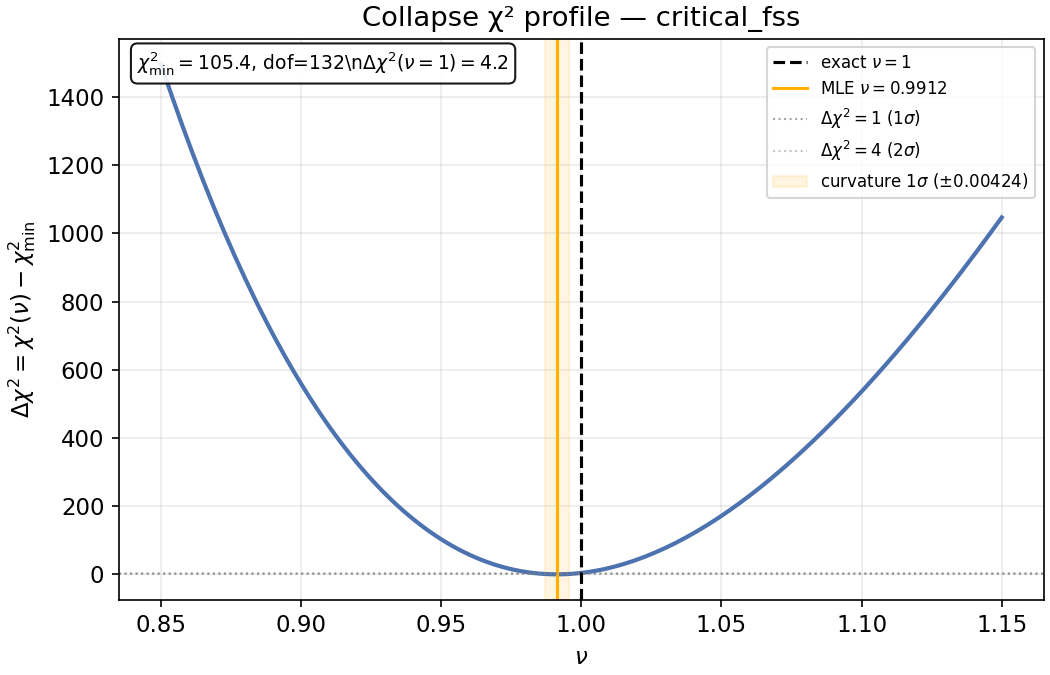

In [8]:
from ising.traditional_scaling import (
    estimate_nu_from_collapse_chi2,
    plot_nu_collapse_chi2_profile,
)

dataset_spec = get_dataset(DATASET)
df_nu = pd.read_csv(data_path)
validate_observables_df(df_nu)

# Use collapse channels that exist in the data and are enabled in config
_nu_channel_map = {"m": "magnetization", "m2": "m2", "m4": "m4"}
nu_channels = tuple(
    ch for ch in COLLAPSE_CHANNELS if ch in _nu_channel_map and _nu_channel_map[ch] in df_nu.columns
)
if not nu_channels:
    nu_channels = ("m",)

NU_COLLAPSE_TC = TC_EXACT
NU_COLLAPSE_BETA = BETA_EXACT
NU_BOUNDS = (0.85, 1.15)

collapse_nu = estimate_nu_from_collapse_chi2(
    df_nu,
    dataset_spec,
    T_c=NU_COLLAPSE_TC,
    beta=NU_COLLAPSE_BETA,
    channels=nu_channels,
    nu_bounds=NU_BOUNDS,
    nu_exact=NU_EXACT,
)

sigma_nu = collapse_nu.nu_stderr
z_score = abs(collapse_nu.nu_hat - NU_EXACT) / sigma_nu if np.isfinite(sigma_nu) and sigma_nu > 0 else float("nan")

print(f"Collapse χ² ν estimate ({DATASET})")
print(f"  Channels: {', '.join(nu_channels)}")
print(f"  Fixed: T_c = {NU_COLLAPSE_TC:.6f}, β = {NU_COLLAPSE_BETA:g}")
print(f"  ν̂ = {collapse_nu.nu_hat:.5f} ± {sigma_nu:.5f}  (curvature, Δχ²=1)")
print(f"  exact ν = {NU_EXACT:g}  →  {z_score:.2f}σ from ν̂")
print(f"  χ²_min = {collapse_nu.chi2_min:.1f},  χ²(ν=1) = {collapse_nu.chi2_exact:.1f},")
print(f"  Δχ²(exact) = {collapse_nu.delta_chi2_exact:.1f}  on {collapse_nu.n_dof} dof")

# --- visualization: Δχ²(ν) and its slope dΔχ²/dν ---
nu_grid = collapse_nu.nu_grid
delta = collapse_nu.delta_chi2
slope = np.gradient(delta, nu_grid)  # numerical slope of the profile

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(nu_grid, delta, color="#4c72b0", linewidth=2.0, label=r"$\Delta\chi^2(\nu)$")
ax.axvline(NU_EXACT, color="black", linestyle="--", linewidth=1.5, label=rf"exact $\nu={NU_EXACT:g}$")
ax.axvline(collapse_nu.nu_hat, color="#ffb000", linewidth=1.5, label=rf"MLE $\hat\nu={collapse_nu.nu_hat:.4f}$")
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.7, label=r"$\Delta\chi^2=1$")
if np.isfinite(sigma_nu):
    ax.axvspan(
        collapse_nu.nu_hat - sigma_nu,
        collapse_nu.nu_hat + sigma_nu,
        color="#ffb000",
        alpha=0.12,
    )
ax.set_xlabel(r"$\nu$")
ax.set_ylabel(r"$\Delta\chi^2$")
ax.set_title(r"Profile: curvature $\rightarrow$ precision")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.25)

ax = axes[1]
ax.plot(nu_grid, slope, color="#55a868", linewidth=2.0, label=r"$ d\Delta\chi^2/ d\nu$")
ax.axvline(collapse_nu.nu_hat, color="#ffb000", linewidth=1.5)
ax.axhline(0.0, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel(r"$\nu$")
ax.set_ylabel(r"$d\Delta\chi^2/ d\nu$")
ax.set_title(r"Slope of profile (zero at $\hat\nu$)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

idx = int(np.argmin(np.abs(nu_grid - collapse_nu.nu_hat)))
ax.annotate(
    rf"slope$_{{\hat\nu}} \approx {slope[idx]:.1f}$",
    xy=(nu_grid[idx], slope[idx]),
    xytext=(12, -20),
    textcoords="offset points",
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="#55a868"),
)

fig.suptitle(
    rf"Binned collapse $\chi^2$ for $\nu$ at $T_c={NU_COLLAPSE_TC:.5f}$, $\beta={NU_COLLAPSE_BETA:g}$ — {DATASET}",
    y=1.03,
)
plt.show()

nu_profile_path = plots_path / "collapse_nu_chi2_profile.png"
plot_nu_collapse_chi2_profile(collapse_nu, nu_profile_path, title=f"Collapse χ² profile — {DATASET}")
plt.close()
print(f"Wrote {nu_profile_path}")
display(Image(filename=nu_profile_path))

## GP profile likelihood vs $\nu$ (interactive)

Pick any **dataset** and **likelihood channels** (m, m², m⁴, Binder, χ). The scatter plot always shows **Binder vs $T$** for masking: **click** a marker, use **L** checkboxes, or the idx slider + **Toggle point**. Grey markers are excluded from the GP likelihood (all active channels).

A **sample divisor** slider (value k ≥ 1) simulates using 1/k the effective MC samples: inferential variance scales ×k, standard errors ×√k, with matching fixed-seed value jitter. GP sliders match `profile_likelihood.py`: **`gp_ell_factor`** and **`gp_eta`**. Per-channel **$L^{-\omega}$ correction** checkboxes apply only when that channel is enabled.

Requires ≥4 included points and at least one likelihood channel.

Below the 1D ν profile is a **2D heatmap** over $(T_c, \nu)$ with $\beta$ fixed at the exact value.

At the bottom, **1D marginal profiles** for $\nu$, $T_c$, and $\beta$ (other exponents fixed at exact values).



In [9]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

from ising.constants import BETA_EXACT, NU_EXACT, TC_EXACT
from ising.datasets import get_dataset, list_datasets, resolve_paths, samples_path
from ising.fit import _profile_config_from_fit_kwargs
from ising.fss_likelihood import (
    compile_fss_log_marginal_likelihood_jax,
)
from ising.gp_kernels import DEFAULT_GP_KERNEL, GpKernelKind
from ising.jax_config import configure_jax, jax_device_summary
from ising.model_fss import (
    BETA_PRIOR_LOWER,
    BETA_PRIOR_UPPER,
    NU_PRIOR_LOWER,
    NU_PRIOR_UPPER,
    TC_PRIOR_LOWER,
    TC_PRIOR_UPPER,
)
from ising.observables import (
    ensure_harada_bsa_observables_csv,
    validate_observables_df,
)
from ising.profile_likelihood import GP_ELL_FACTOR, GP_ETA, USE_LOG_M
from ising.samples import observables_csv_stale_vs_samples

import importlib
import ising.explorer_inference as _explorer_inference
importlib.reload(_explorer_inference)
from ising.explorer_inference import (
    WIDGET_LAPS_CHAINS,
    WIDGET_LAPS_DRAWS,
    WIDGET_LAPS_TUNE,
    build_posterior_figure_widget,
    build_preview_posterior_figure_widget,
    clear_preview_posterior_figure,
    posterior_heatmap_from_idata,
    preview_include_point,
    preview_status_html,
    run_widget_laps_inference,
    update_posterior_figure_base,
    update_preview_posterior_figure,
)

configure_jax()
print(jax_device_summary(), flush=True)

PROFILE_TC = TC_EXACT
PROFILE_BETA = BETA_EXACT
PROFILE_N_POINTS = 60
BINDER_PLOT_WIDTH = 420
BINDER_PLOT_HEIGHT = 220
PROFILE_PLOT_WIDTH = 420
PROFILE_PLOT_HEIGHT = 220
JOINT_HEATMAP_HEIGHT = 280
JOINT_HEATMAP_Z_FLOOR = -80.0
JOINT_HEATMAP_N_DEFAULT = 35

POSTERIOR_PLOT_HEIGHT = 280
try:
    _DEFAULT_INFER_TC = INFER_TC
    _DEFAULT_INFER_NU = INFER_NU
    _DEFAULT_INFER_BETA = INFER_BETA
except NameError:
    _DEFAULT_INFER_TC = True
    _DEFAULT_INFER_NU = True
    _DEFAULT_INFER_BETA = False
NOISE_SEED = 0
SAMPLE_DIVISOR_MAX = 500.0
# (value col, batch-std col, n_eff col) — divisor k simulates n_eff' = n_eff / k
_NOISE_CHANNEL_SPECS: tuple[tuple[str, str, str], ...] = (
    ("magnetization", "magnetization_std", "n_eff"),
    ("log_magnetization", "log_magnetization_std", "n_eff_log"),
    ("m2", "m2_std", "n_eff_m2"),
    ("m4", "m4_std", "n_eff_m4"),
    ("binder_cumulant", "binder_cumulant_std", "n_eff_binder"),
    ("susceptibility", "susceptibility_std", "n_eff_susceptibility"),
)

KERNEL_LABELS: dict[GpKernelKind, str] = {
    "matern52": "Matérn-5/2",
    "gaussian": "RBF",
}
_BINDER_ONLY_DATASETS = frozenset({"harada_bsa"})
_CHANNEL_NAMES = ("m", "m2", "m4", "binder", "chi")
_PLOTLY_COLORS = (
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
)
_PLOTLY_SYMBOLS = (
    "circle",
    "square",
    "diamond",
    "cross",
    "x",
    "triangle-up",
    "star",
    "hexagon",
)

try:
    _INITIAL_DATASET = DATASET
except NameError:
    _INITIAL_DATASET = "harada_bsa"

_current_dataset = _INITIAL_DATASET
_obs_df_clean = pd.DataFrame()
_obs_df = pd.DataFrame()
_noise_units: dict[str, np.ndarray] = {}
_observables_stale_warning: str | None = None
PICK_INCLUDED = np.array([], dtype=bool)


def _profile_grid(lo: float, hi: float, exact: float, n: int) -> np.ndarray:
    grid = np.linspace(lo, hi, n)
    if lo <= exact <= hi and not np.any(np.isclose(grid, exact, rtol=0.0, atol=1e-10)):
        grid = np.sort(np.append(grid, exact))
    return grid


_nu_profile_grid = _profile_grid(NU_PRIOR_LOWER, NU_PRIOR_UPPER, NU_EXACT, PROFILE_N_POINTS)
_tc_profile_grid = _profile_grid(TC_PRIOR_LOWER, TC_PRIOR_UPPER, TC_EXACT, PROFILE_N_POINTS)
_beta_profile_grid = _profile_grid(
    BETA_PRIOR_LOWER, BETA_PRIOR_UPPER, BETA_EXACT, PROFILE_N_POINTS
)

_compiled_by_key: dict[tuple, object] = {}
_updating_L_checks = False
_updating_binder_plot = False

_profile_fig_widget: go.FigureWidget | None = None
_tc_profile_fig_widget: go.FigureWidget | None = None
_beta_profile_fig_widget: go.FigureWidget | None = None
_joint_fig_widget: go.FigureWidget | None = None
_binder_fig: go.FigureWidget | None = None
_profile_status = widgets.HTML(value="")
_data_status = widgets.HTML(value="")

_posterior_fig_widget: go.FigureWidget | None = None
_preview_posterior_fig_widget: go.FigureWidget | None = None
_inference_idata = None
_inference_heatmap = None
_inference_stale = True
_preview_result = None
_preview_row_index: int | None = None
_inference_status = widgets.HTML(value="")


def _l_style(L: int, index: int) -> dict[str, object]:
    return {
        "color": _PLOTLY_COLORS[index % len(_PLOTLY_COLORS)],
        "symbol": _PLOTLY_SYMBOLS[index % len(_PLOTLY_SYMBOLS)],
        "size": 9,
        "label": rf"$L={L}$",
    }


def _L_values() -> tuple[int, ...]:
    return tuple(sorted(_obs_df["L"].unique()))


def _channel_available(channel: str) -> bool:
    if channel == "binder":
        return True
    return _current_dataset not in _BINDER_ONLY_DATASETS


def _default_channel_state(dataset: str) -> dict[str, bool]:
    if dataset in _BINDER_ONLY_DATASETS:
        return {
            "use_m": False,
            "use_m2": False,
            "use_m4": False,
            "use_binder": True,
            "use_chi": False,
            "correction_m": False,
            "correction_m2": False,
            "correction_m4": False,
            "correction_binder": True,
            "correction_chi": False,
        }
    return {
        "use_m": USE_M,
        "use_m2": USE_M2,
        "use_m4": USE_M4,
        "use_binder": USE_BINDER,
        "use_chi": USE_CHI,
        "correction_m": CORRECTION_M,
        "correction_m2": CORRECTION_M2,
        "correction_m4": CORRECTION_M4,
        "correction_binder": CORRECTION_BINDER,
        "correction_chi": CORRECTION_CHI,
    }


def _load_observables_table(dataset: str) -> pd.DataFrame:
    global _observables_stale_warning

    data_path, _, _ = resolve_paths(dataset)
    if dataset == "harada_bsa":
        data_path = ensure_harada_bsa_observables_csv(data_path)
    if not Path(data_path).exists():
        raise FileNotFoundError(
            f"Missing {data_path}; run simulate for {dataset!r} first."
        )
    sample_file = samples_path(dataset)
    if observables_csv_stale_vs_samples(dataset, data=data_path, samples=sample_file):
        _observables_stale_warning = (
            f"{data_path.name} is older than {sample_file.name}. "
            f"Rebuild: python -m ising.simulate "
            f"--dataset {dataset} --aggregate-samples {sample_file}"
        )
    else:
        _observables_stale_warning = None
    df = pd.read_csv(data_path).reset_index(drop=True)
    validate_observables_df(df, use_binder=True)
    return df


def _regenerate_noise_units(n: int) -> None:
    global _noise_units
    rng = np.random.default_rng(NOISE_SEED)
    _noise_units = {
        val_col: rng.standard_normal(n)
        for val_col, _, _ in _NOISE_CHANNEL_SPECS
    }


def _apply_sample_divisor_noise(df: pd.DataFrame, sample_divisor: float) -> pd.DataFrame:
    """Simulate n_eff' = n_eff / k (inferential variance × k)."""
    k = float(sample_divisor)
    if k <= 1.0:
        return df.copy()
    out = df.copy()
    std_scale = np.sqrt(k)
    for val_col, std_col, neff_col in _NOISE_CHANNEL_SPECS:
        if val_col not in out.columns or std_col not in out.columns:
            continue
        vals = out[val_col].to_numpy(dtype=np.float64, copy=True)
        std_batch = out[std_col].to_numpy(dtype=np.float64)
        if neff_col in out.columns:
            n_eff = np.maximum(out[neff_col].to_numpy(dtype=np.float64, copy=False), 1.0)
        else:
            n_eff = np.ones(len(out), dtype=np.float64)
        active = np.isfinite(vals) & np.isfinite(std_batch) & (std_batch > 0.0)
        if active.any() and val_col in _noise_units:
            extra_infer_sigma = np.sqrt((k - 1.0) * (std_batch[active] ** 2) / n_eff[active])
            unit = _noise_units[val_col]
            vals[active] = vals[active] + extra_infer_sigma * unit[active]
            out[val_col] = vals
        std_mask = np.isfinite(std_batch) & (std_batch > 0.0)
        if std_mask.any():
            stds = std_batch.copy()
            stds[std_mask] = std_batch[std_mask] * std_scale
            out[std_col] = stds
    return out


def _refresh_noisy_obs() -> None:
    global _obs_df
    _obs_df = _apply_sample_divisor_noise(
        _obs_df_clean, float(_sample_divisor_slider.value)
    )


def _mask_key() -> tuple[bool, ...]:
    return tuple(bool(x) for x in PICK_INCLUDED)


def _channel_kwargs() -> dict[str, bool]:
    return {
        "use_m": bool(_ch_m.value),
        "use_m2": bool(_ch_m2.value),
        "use_m4": bool(_ch_m4.value),
        "use_binder": bool(_ch_binder.value),
        "use_chi": bool(_ch_chi.value),
        "correction_m": bool(_ch_m.value) and bool(_corr_m.value),
        "correction_m2": bool(_ch_m2.value) and bool(_corr_m2.value),
        "correction_m4": bool(_ch_m4.value) and bool(_corr_m4.value),
        "correction_binder": bool(_ch_binder.value) and bool(_corr_binder.value),
        "correction_chi": bool(_ch_chi.value) and bool(_corr_chi.value),
    }


def _flipped_correction_kwargs() -> dict[str, bool]:
    ch = _channel_kwargs()
    flipped = dict(ch)
    for name in _CHANNEL_NAMES:
        use_key = f"use_{name}"
        corr_key = f"correction_{name}"
        if ch[use_key]:
            flipped[corr_key] = not ch[corr_key]
    return flipped


def _any_channel_enabled() -> bool:
    ch = _channel_kwargs()
    return any(ch[f"use_{name}"] for name in _CHANNEL_NAMES)


def _full_settings_key(
    gp_kernel: GpKernelKind,
    gp_ell_factor: float,
    gp_eta: float,
    channel_state: dict[str, bool],
) -> tuple:
    ch_tuple = tuple(channel_state[k] for k in sorted(channel_state))
    return (
        _current_dataset,
        _mask_key(),
        ch_tuple,
        gp_kernel,
        round(float(gp_ell_factor), 8),
        round(float(gp_eta), 8),
        round(float(_sample_divisor_slider.value), 8),
    )


def _invalidate_profile_cache() -> None:
    _compiled_by_key.clear()


def _build_profile_config(
    gp_kernel: GpKernelKind,
    gp_ell_factor: float,
    gp_eta: float,
    channel_state: dict[str, bool] | None = None,
):
    ch = channel_state if channel_state is not None else _channel_kwargs()
    return _profile_config_from_fit_kwargs(
        use_m=ch["use_m"],
        use_m2=ch["use_m2"],
        use_m4=ch["use_m4"],
        use_binder=ch["use_binder"],
        use_chi=ch["use_chi"],
        correction_m=ch["correction_m"],
        correction_m2=ch["correction_m2"],
        correction_m4=ch["correction_m4"],
        correction_binder=ch["correction_binder"],
        correction_chi=ch["correction_chi"],
        use_log_m=USE_LOG_M,
        gp_ell_factor=float(gp_ell_factor),
        gp_eta=float(gp_eta),
        correction_gp_ell_factor=None,
        correction_gp_eta=None,
        gp_kernel=gp_kernel,
        obs_sigma_scale=1.0,
        **_infer_kwargs(),
    )


def _active_profile_obs() -> pd.DataFrame:
    ch = _channel_kwargs()
    n_in = int(PICK_INCLUDED.sum())
    if n_in < 4:
        raise ValueError(
            f"Need at least 4 included points for the GP likelihood (have {n_in})."
        )
    masked = _obs_df.loc[PICK_INCLUDED].reset_index(drop=True)
    validate_observables_df(
        masked,
        use_m=ch["use_m"],
        use_m2=ch["use_m2"],
        use_m4=ch["use_m4"],
        use_binder=ch["use_binder"],
        use_chi=ch["use_chi"],
    )
    return masked


def _get_compiled(
    gp_kernel: GpKernelKind,
    gp_ell_factor: float,
    gp_eta: float,
    channel_state: dict[str, bool] | None = None,
):
    ch = channel_state if channel_state is not None else _channel_kwargs()
    key = _full_settings_key(gp_kernel, gp_ell_factor, gp_eta, ch)
    compiled = _compiled_by_key.get(key)
    if compiled is None:
        obs = _active_profile_obs()
        config = _build_profile_config(gp_kernel, gp_ell_factor, gp_eta, ch)
        compiled = compile_fss_log_marginal_likelihood_jax(obs, config)
        _compiled_by_key[key] = compiled
    return compiled


def _profile_nu_log_ml(
    gp_kernel: GpKernelKind,
    gp_ell_factor: float,
    gp_eta: float,
    channel_state: dict[str, bool] | None = None,
) -> np.ndarray:
    compiled = _get_compiled(
        gp_kernel, gp_ell_factor, gp_eta, channel_state=channel_state
    )
    return np.asarray(
        compiled.profile_nu(_nu_profile_grid, PROFILE_TC, PROFILE_BETA),
        dtype=np.float64,
    )


def _profile_tc_log_ml(
    gp_kernel: GpKernelKind,
    gp_ell_factor: float,
    gp_eta: float,
    channel_state: dict[str, bool] | None = None,
) -> np.ndarray:
    compiled = _get_compiled(
        gp_kernel, gp_ell_factor, gp_eta, channel_state=channel_state
    )
    return np.asarray(
        compiled.profile_tc(_tc_profile_grid, NU_EXACT, PROFILE_BETA),
        dtype=np.float64,
    )


def _profile_beta_log_ml(
    gp_kernel: GpKernelKind,
    gp_ell_factor: float,
    gp_eta: float,
    channel_state: dict[str, bool] | None = None,
) -> np.ndarray:
    compiled = _get_compiled(
        gp_kernel, gp_ell_factor, gp_eta, channel_state=channel_state
    )
    return np.asarray(
        compiled.profile_beta(_beta_profile_grid, PROFILE_TC, NU_EXACT),
        dtype=np.float64,
    )


def _joint_grids(n_points: int) -> tuple[np.ndarray, np.ndarray]:
    n = int(n_points)
    return (
        _profile_grid(TC_PRIOR_LOWER, TC_PRIOR_UPPER, TC_EXACT, n),
        _profile_grid(NU_PRIOR_LOWER, NU_PRIOR_UPPER, NU_EXACT, n),
    )


def _profile_joint_tc_nu_log_ml(
    gp_kernel: GpKernelKind,
    gp_ell_factor: float,
    gp_eta: float,
    *,
    n_points: int,
    channel_state: dict[str, bool] | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    tc_grid, nu_grid = _joint_grids(n_points)
    compiled = _get_compiled(
        gp_kernel, gp_ell_factor, gp_eta, channel_state=channel_state
    )
    log_ml = np.asarray(
        compiled.profile_joint(
            tc_grid,
            nu_grid,
            "T_c_nu",
            TC_EXACT,
            NU_EXACT,
            PROFILE_BETA,
        ),
        dtype=np.float64,
    )
    return tc_grid, nu_grid, log_ml


def _point_color(idx: int) -> str:
    if PICK_INCLUDED[idx]:
        L = int(_obs_df.iloc[idx]["L"])
        for i, Lval in enumerate(_L_values()):
            if int(Lval) == L:
                return str(_l_style(L, i)["color"])
        return _PLOTLY_COLORS[0]
    return "rgba(120, 120, 120, 0.45)"


def _active_channel_label() -> str:
    ch = _channel_kwargs()
    parts = [name for name in _CHANNEL_NAMES if ch[f"use_{name}"]]
    return ", ".join(parts) if parts else "none"


def _correction_label() -> str:
    ch = _channel_kwargs()
    parts = [
        name
        for name in _CHANNEL_NAMES
        if ch[f"use_{name}"] and ch[f"correction_{name}"]
    ]
    return ", ".join(parts) if parts else "none"


def _build_profile_figure_widget() -> go.FigureWidget:
    return _build_1d_marginal_widget(r"$\nu$")


def _build_1d_marginal_widget(xaxis_title: str) -> go.FigureWidget:
    return go.FigureWidget(
        data=[
            go.Scatter(
                x=[],
                y=[],
                mode="lines",
                line=dict(color="#4c72b0", width=2.0),
            ),
        ],
        layout=go.Layout(
            xaxis_title=xaxis_title,
            yaxis_title=r"$\log p(\mathrm{data}\mid \cdot)$ (shifted)",
            width=PROFILE_PLOT_WIDTH,
            height=PROFILE_PLOT_HEIGHT,
            template="plotly_white",
            margin=dict(l=48, r=16, t=44, b=40),
        ),
    )


def _update_1d_marginal_widget(
    fig: go.FigureWidget | None,
    *,
    grid: np.ndarray,
    log_ml: np.ndarray,
    exact_value: float,
    exact_label: str,
    mle_name: str,
    title: str,
) -> float:
    y = np.asarray(log_ml - np.max(log_ml), dtype=np.float64)
    mle = float(grid[int(np.argmax(log_ml))])
    with fig.batch_update():
        fig.data[0].update(x=grid.tolist(), y=y.tolist())
        fig.update_layout(
            title=dict(text=title, font=dict(size=11)),
            shapes=[
                dict(
                    type="line",
                    x0=exact_value,
                    x1=exact_value,
                    y0=0,
                    y1=1,
                    yref="paper",
                    line=dict(color="black", dash="dash", width=1.2),
                ),
                dict(
                    type="line",
                    x0=mle,
                    x1=mle,
                    y0=0,
                    y1=1,
                    yref="paper",
                    line=dict(color="#c44e52", dash="dot", width=1.2),
                ),
            ],
            annotations=[
                dict(
                    x=exact_value,
                    y=1,
                    yref="paper",
                    text=exact_label,
                    showarrow=False,
                    font=dict(size=9),
                    xanchor="right",
                    yanchor="bottom",
                ),
                dict(
                    x=mle,
                    y=1,
                    yref="paper",
                    text=rf"MLE ${mle_name}={mle:.4f}$",
                    showarrow=False,
                    font=dict(size=9),
                    xanchor="left",
                    yanchor="bottom",
                ),
            ],
        )
    return mle


def _build_joint_heatmap_widget() -> go.FigureWidget:
    tc_grid, nu_grid = _joint_grids(JOINT_HEATMAP_N_DEFAULT)
    z0 = np.full((nu_grid.size, tc_grid.size), JOINT_HEATMAP_Z_FLOOR, dtype=np.float64)
    return go.FigureWidget(
        data=[
            go.Heatmap(
                x=tc_grid,
                y=nu_grid,
                z=z0,
                colorscale="Viridis",
                zmin=JOINT_HEATMAP_Z_FLOOR,
                zmax=0.0,
                colorbar=dict(title="shifted log p", len=0.9),
            ),
            go.Scatter(
                x=[TC_EXACT],
                y=[NU_EXACT],
                mode="markers",
                marker=dict(
                    symbol="star",
                    size=11,
                    color="white",
                    line=dict(width=1.2, color="black"),
                ),
                name="exact",
            ),
            go.Scatter(
                x=[TC_EXACT],
                y=[NU_EXACT],
                mode="markers",
                marker=dict(
                    symbol="x",
                    size=12,
                    color="#c44e52",
                    line=dict(width=1.5, color="white"),
                ),
                name="2D MLE",
            ),
        ],
        layout=go.Layout(
            xaxis_title=r"$T_c$",
            yaxis_title=r"$\nu$",
            width=PROFILE_PLOT_WIDTH,
            height=JOINT_HEATMAP_HEIGHT,
            template="plotly_white",
            margin=dict(l=48, r=16, t=44, b=40),
            legend=dict(font=dict(size=9), yanchor="top", y=0.99, xanchor="left", x=0.01),
        ),
    )


def _data_status_text() -> str:
    n_in = int(PICK_INCLUDED.sum())
    n_tot = len(_obs_df)
    spec = get_dataset(_current_dataset)
    parts: list[str] = []
    for L in _L_values():
        mask = _obs_df["L"] == L
        n_l = int((PICK_INCLUDED & mask.to_numpy()).sum())
        n_l_tot = int(mask.sum())
        parts.append(f"L={L}: {n_l}/{n_l_tot}")
    text = (
        f"<b>{_current_dataset}</b> ({n_tot} pts, {spec.n_sweeps} sweeps, sample÷{float(_sample_divisor_slider.value):.3g}) — "
        f"<b>{n_in}/{n_tot}</b> in likelihood"
        + (f" ({n_tot - n_in} excluded)" if n_in < n_tot else "")
        + " — " + ", ".join(parts)
        + " — <i>click a marker to toggle it</i>"
    )
    if _observables_stale_warning:
        text += f"<br><span style='color:#c44e52'>{_observables_stale_warning}</span>"
    return text


def _selected_point_text(idx: int) -> str:
    row = _obs_df.iloc[idx]
    state = "included" if PICK_INCLUDED[idx] else "excluded"
    return (
        f"Point idx={idx}: L={int(row['L'])}, T={row['T']:.4f}, "
        f"U4={row['binder_cumulant']:.4f} ({state})"
    )


def _rebuild_binder_figure() -> None:
    global _binder_fig
    _binder_fig = _build_binder_figure_widget()
    _binder_fig_box.children = (_binder_fig,)


def _binder_L_traces():
    """Per-L scatter traces only (exclude preview-add overlay trace)."""
    n = len(_L_values())
    return _binder_fig.data[:n] if _binder_fig is not None else ()


def _binder_preview_trace_idx() -> int:
    return len(_L_values())


def _update_binder_widget_from_mask() -> None:
    global _updating_binder_plot
    if _binder_fig is None:
        return
    _updating_binder_plot = True
    try:
        with _binder_fig.batch_update():
            for trace, L in zip(_binder_L_traces(), _L_values(), strict=True):
                mask = _obs_df["L"] == L
                indices = np.flatnonzero(mask.to_numpy())
                n_in = int((PICK_INCLUDED & mask.to_numpy()).sum())
                y_vals = _obs_df.loc[mask, "binder_cumulant"].to_numpy(dtype=np.float64).tolist()
                colors = [_point_color(int(i)) for i in indices]
                trace.update(
                    visible=n_in > 0,
                    y=y_vals,
                    marker=dict(color=colors),
                )
    finally:
        _updating_binder_plot = False


def _on_binder_point_click(trace, points, state) -> None:
    if _updating_binder_plot or not points.point_inds:
        return
    idx = int(trace.customdata[points.point_inds[0]])
    if (not PICK_INCLUDED[idx]) and (_click_is_shift(state) or bool(_preview_mode_cb.value)):
        _preview_add_point_idx(idx)
        return
    _toggle_point_idx(idx)


def _build_binder_figure_widget() -> go.FigureWidget:
    fig = go.FigureWidget()
    for i, L in enumerate(_L_values()):
        mask = _obs_df["L"] == L
        indices = np.flatnonzero(mask.to_numpy())
        style = _l_style(int(L), i)
        fig.add_trace(
            go.Scatter(
                x=_obs_df.loc[mask, "T"].to_numpy(dtype=np.float64).tolist(),
                y=_obs_df.loc[mask, "binder_cumulant"].to_numpy(dtype=np.float64).tolist(),
                customdata=indices,
                mode="markers",
                name=str(style["label"]),
                marker=dict(
                    symbol=style["symbol"],
                    size=style["size"],
                    color=[_point_color(int(j)) for j in indices],
                    line=dict(width=1.2, color="rgba(0, 0, 0, 0.35)"),
                ),
                hovertemplate=(
                    f"idx=%{{customdata}}<br>L={int(L)}<br>T=%{{x:.4f}}"
                    f"<br>U4=%{{y:.4f}}<extra></extra>"
                ),
            )
        )
        fig.data[-1].on_click(_on_binder_point_click)
    fig.add_vline(
        x=TC_EXACT,
        line=dict(color="red", dash="dashdot", width=1.2),
        annotation_text=rf"exact $T_c={TC_EXACT:.4f}$",
        annotation_position="top right",
        annotation_font_size=10,
    )
    fig.update_layout(
        title=dict(
            text=f"{_current_dataset} — Binder (grey = excluded)",
            font=dict(size=12),
        ),
        xaxis_title=r"$T$",
        yaxis_title=r"$U_4$",
        width=BINDER_PLOT_WIDTH,
        height=BINDER_PLOT_HEIGHT,
        template="plotly_white",
        margin=dict(l=48, r=16, t=44, b=40),
        legend=dict(font=dict(size=9), itemclick=False, itemdoubleclick=False),
        hovermode="closest",
    )
    fig.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode="markers",
            name="preview add",
            visible=False,
            marker=dict(symbol="star", size=16, color="#e6a817"),
            hoverinfo="skip",
        )
    )
    return fig


def _draw_nu_profile(
    gp_ell_factor: float,
    gp_eta: float,
    gp_kernel: GpKernelKind,
) -> tuple[float, float, float] | None:
    if _profile_fig_widget is None:
        return None

    obs_len = int(PICK_INCLUDED.sum())
    if obs_len < 4 or not _any_channel_enabled():
        return None

    t0 = time.perf_counter()
    ch = _channel_kwargs()
    log_ml = _profile_nu_log_ml(gp_kernel, gp_ell_factor, gp_eta, channel_state=ch)
    log_ml_other = _profile_nu_log_ml(
        gp_kernel,
        gp_ell_factor,
        gp_eta,
        channel_state=_flipped_correction_kwargs(),
    )
    elapsed = time.perf_counter() - t0

    y = np.asarray(log_ml - np.max(log_ml), dtype=np.float64)
    y_other = np.asarray(log_ml_other - np.max(log_ml_other), dtype=np.float64)
    tail_delta = float(np.max(np.abs(y - y_other)))
    title = (
        rf"$\nu$ profile — {KERNEL_LABELS[gp_kernel]}, "
        rf"$T_c={PROFILE_TC:.4g}$, $\beta={PROFILE_BETA:.4g}$ fixed, $n={obs_len}$"
    )
    mle_nu = _update_1d_marginal_widget(
        _profile_fig_widget,
        grid=_nu_profile_grid,
        log_ml=log_ml,
        exact_value=NU_EXACT,
        exact_label=rf"exact $\nu={NU_EXACT:.4g}$",
        mle_name=r"\nu",
        title=title,
    )

    return elapsed, mle_nu, tail_delta


def _draw_tc_profile(
    gp_ell_factor: float,
    gp_eta: float,
    gp_kernel: GpKernelKind,
) -> tuple[float, float] | None:
    if _tc_profile_fig_widget is None:
        return None

    obs_len = int(PICK_INCLUDED.sum())
    if obs_len < 4 or not _any_channel_enabled():
        return None

    t0 = time.perf_counter()
    log_ml = _profile_tc_log_ml(gp_kernel, gp_ell_factor, gp_eta)
    elapsed = time.perf_counter() - t0
    title = (
        rf"$T_c$ profile — {KERNEL_LABELS[gp_kernel]}, "
        rf"$\nu={NU_EXACT:.4g}$, $\beta={PROFILE_BETA:.4g}$ fixed, $n={obs_len}$"
    )
    mle_tc = _update_1d_marginal_widget(
        _tc_profile_fig_widget,
        grid=_tc_profile_grid,
        log_ml=log_ml,
        exact_value=TC_EXACT,
        exact_label=rf"exact $T_c={TC_EXACT:.4f}$",
        mle_name="T_c",
        title=title,
    )
    return elapsed, mle_tc


def _draw_beta_profile(
    gp_ell_factor: float,
    gp_eta: float,
    gp_kernel: GpKernelKind,
) -> tuple[float, float] | None:
    if _beta_profile_fig_widget is None:
        return None

    obs_len = int(PICK_INCLUDED.sum())
    if obs_len < 4 or not _any_channel_enabled():
        return None

    t0 = time.perf_counter()
    log_ml = _profile_beta_log_ml(gp_kernel, gp_ell_factor, gp_eta)
    elapsed = time.perf_counter() - t0
    title = (
        rf"$\beta$ profile — {KERNEL_LABELS[gp_kernel]}, "
        rf"$T_c={PROFILE_TC:.4g}$, $\nu={NU_EXACT:.4g}$ fixed, $n={obs_len}$"
    )
    mle_beta = _update_1d_marginal_widget(
        _beta_profile_fig_widget,
        grid=_beta_profile_grid,
        log_ml=log_ml,
        exact_value=BETA_EXACT,
        exact_label=rf"exact $\beta={BETA_EXACT:.4g}$",
        mle_name=r"\beta",
        title=title,
    )
    return elapsed, mle_beta


def _draw_joint_heatmap(
    gp_ell_factor: float,
    gp_eta: float,
    gp_kernel: GpKernelKind,
    *,
    n_points: int,
) -> tuple[float, float, float, float] | None:
    if _joint_fig_widget is None:
        return None

    obs_len = int(PICK_INCLUDED.sum())
    if obs_len < 4 or not _any_channel_enabled():
        return None

    t0 = time.perf_counter()
    tc_grid, nu_grid, log_ml = _profile_joint_tc_nu_log_ml(
        gp_kernel,
        gp_ell_factor,
        gp_eta,
        n_points=n_points,
    )
    elapsed = time.perf_counter() - t0

    z = np.asarray(log_ml - np.max(log_ml), dtype=np.float64)
    z = np.maximum(z, JOINT_HEATMAP_Z_FLOOR)
    mle_j, mle_i = np.unravel_index(int(np.argmax(log_ml)), log_ml.shape)
    mle_tc = float(tc_grid[mle_i])
    mle_nu = float(nu_grid[mle_j])
    exact_delta = float(
        log_ml[
            np.argmin(np.abs(nu_grid - NU_EXACT)),
            np.argmin(np.abs(tc_grid - TC_EXACT)),
        ]
        - np.max(log_ml)
    )

    with _joint_fig_widget.batch_update():
        _joint_fig_widget.data[0].update(
            x=tc_grid.tolist(),
            y=nu_grid.tolist(),
            z=z.tolist(),
        )
        _joint_fig_widget.data[1].update(x=[TC_EXACT], y=[NU_EXACT])
        _joint_fig_widget.data[2].update(x=[mle_tc], y=[mle_nu])
        _joint_fig_widget.update_layout(
            title=dict(
                text=(
                    rf"Joint profile — {KERNEL_LABELS[gp_kernel]}, "
                    rf"channels: {_active_channel_label()}, "
                    rf"corr: {_correction_label()}, "
                    rf"$\beta={PROFILE_BETA:.4g}$ fixed, $n={obs_len}$, "
                    rf"grid={int(n_points)}$\times${int(n_points)}"
                ),
                font=dict(size=11),
            ),
        )

    return elapsed, mle_tc, mle_nu, exact_delta


def _sync_L_checkboxes() -> None:
    global _updating_L_checks
    _updating_L_checks = True
    try:
        for L, cb in _L_checks.items():
            mask = _obs_df["L"] == L
            n_l_tot = int(mask.sum())
            n_l_in = int((PICK_INCLUDED & mask.to_numpy()).sum())
            cb.value = n_l_in == n_l_tot
    finally:
        _updating_L_checks = False


def _sync_correction_enabled() -> None:
    pairs = (
        (_ch_m, _corr_m),
        (_ch_m2, _corr_m2),
        (_ch_m4, _corr_m4),
        (_ch_binder, _corr_binder),
        (_ch_chi, _corr_chi),
    )
    for ch_cb, corr_cb in pairs:
        corr_cb.disabled = not bool(ch_cb.value)


def _apply_channel_defaults(defaults: dict[str, bool]) -> None:
    _ch_m.value = defaults["use_m"]
    _ch_m2.value = defaults["use_m2"]
    _ch_m4.value = defaults["use_m4"]
    _ch_binder.value = defaults["use_binder"]
    _ch_chi.value = defaults["use_chi"]
    _corr_m.value = defaults["correction_m"]
    _corr_m2.value = defaults["correction_m2"]
    _corr_m4.value = defaults["correction_m4"]
    _corr_binder.value = defaults["correction_binder"]
    _corr_chi.value = defaults["correction_chi"]


def _update_channel_availability() -> None:
    channel_cbs = {
        "m": _ch_m,
        "m2": _ch_m2,
        "m4": _ch_m4,
        "binder": _ch_binder,
        "chi": _ch_chi,
    }
    corr_cbs = {
        "m": _corr_m,
        "m2": _corr_m2,
        "m4": _corr_m4,
        "binder": _corr_binder,
        "chi": _corr_chi,
    }
    for name, cb in channel_cbs.items():
        available = _channel_available(name)
        cb.disabled = not available
        corr_cbs[name].disabled = not available or not bool(cb.value)
        if not available:
            cb.value = False
            corr_cbs[name].value = False
    _sync_correction_enabled()


def _profile_control_values() -> tuple[float, float, GpKernelKind]:
    return (
        _ell_factor_slider.value,
        _eta_slider.value,
        _kernel_toggle.value,
    )


def _draw_profiles_from_controls() -> None:
    gp_ell_factor, gp_eta, gp_kernel = _profile_control_values()
    n_2d = int(_heatmap_n_slider.value)
    obs_len = int(PICK_INCLUDED.sum())
    if not _any_channel_enabled():
        _profile_status.value = (
            "<span style='color:#c44e52'>Enable at least one likelihood channel.</span>"
        )
        return
    if obs_len < 4:
        _profile_status.value = (
            f"<span style='color:#c44e52'>Need ≥4 included points (have {obs_len}).</span>"
        )
        return
    result_1d = _draw_nu_profile(gp_ell_factor, gp_eta, gp_kernel)
    result_2d = _draw_joint_heatmap(
        gp_ell_factor,
        gp_eta,
        gp_kernel,
        n_points=n_2d,
    )
    result_tc = _draw_tc_profile(gp_ell_factor, gp_eta, gp_kernel)
    result_beta = _draw_beta_profile(gp_ell_factor, gp_eta, gp_kernel)
    if result_1d is None or result_2d is None or result_tc is None or result_beta is None:
        return
    elapsed_1d, mle_nu_1d, tail_delta = result_1d
    elapsed_2d, mle_tc, mle_nu_2d, exact_delta = result_2d
    elapsed_tc, mle_tc_1d = result_tc
    elapsed_beta, mle_beta_1d = result_beta
    _profile_status.value = (
        f"Updated (1D ν {elapsed_1d:.2f}s, T_c {elapsed_tc:.2f}s, β {elapsed_beta:.2f}s, "
        f"2D {elapsed_2d:.2f}s). "
        f"channels=[{_active_channel_label()}], corr=[{_correction_label()}]. "
        f"1D MLE ν={mle_nu_1d:.4f}, T_c={mle_tc_1d:.4f}, β={mle_beta_1d:.4f}; "
        f"2D MLE T_c={mle_tc:.4f}, ν={mle_nu_2d:.4f}; "
        f"exact Δlog p={exact_delta:.4g}; 1D max |Δy| vs flipped corr={tail_delta:.4g}."
    )


def _after_mask_change(*, update_slider_idx: int | None) -> None:
    _invalidate_profile_cache()
    _invalidate_inference()
    if update_slider_idx is not None:
        _point_index_slider.value = int(update_slider_idx)
    _update_binder_widget_from_mask()
    _data_status.value = _data_status_text()
    _point_info.value = _selected_point_text(int(_point_index_slider.value))
    _sync_L_checkboxes()
    _draw_profiles_from_controls()


def _refresh_all() -> None:
    _update_binder_widget_from_mask()
    _data_status.value = _data_status_text()
    _point_info.value = _selected_point_text(int(_point_index_slider.value))
    _sync_L_checkboxes()
    _draw_profiles_from_controls()


def _set_L_included(L: int, included: bool) -> None:
    PICK_INCLUDED[_obs_df["L"].to_numpy() == L] = included
    _after_mask_change(update_slider_idx=None)


def _toggle_point_idx(idx: int) -> None:
    PICK_INCLUDED[idx] = not bool(PICK_INCLUDED[idx])
    _after_mask_change(update_slider_idx=idx)


def _toggle_selected_point(_btn=None) -> None:
    _toggle_point_idx(int(_point_index_slider.value))


def _include_all_points(_btn=None) -> None:
    PICK_INCLUDED[:] = True
    _after_mask_change(update_slider_idx=None)


def _rebuild_L_checkboxes() -> None:
    global _L_checks
    _L_checks = {}
    children = []
    for L in _L_values():
        cb = widgets.Checkbox(value=True, description=f"include L={L}")

        def _make_L_handler(Lval: int):
            def _handler(change: dict) -> None:
                if change.get("name") != "value" or _updating_L_checks:
                    return
                _set_L_included(Lval, bool(change["new"]))

            return _handler

        cb.observe(_make_L_handler(int(L)), names="value")
        _L_checks[int(L)] = cb
        children.append(cb)
    _L_checks_box.children = tuple(children)


def _switch_dataset(dataset: str) -> None:
    global _current_dataset, _obs_df_clean, _obs_df, PICK_INCLUDED, _binder_fig
    _current_dataset = dataset
    try:
        _obs_df_clean = _load_observables_table(dataset)
    except FileNotFoundError as exc:
        _data_status.value = f"<span style='color:#c44e52'>{exc}</span>"
        _profile_status.value = _data_status.value
        return

    _regenerate_noise_units(len(_obs_df_clean))
    _refresh_noisy_obs()
    PICK_INCLUDED = np.ones(len(_obs_df), dtype=bool)
    _apply_channel_defaults(_default_channel_state(dataset))
    _update_channel_availability()

    _rebuild_L_checkboxes()
    _rebuild_binder_figure()

    _point_index_slider.max = max(0, len(_obs_df) - 1)
    _point_index_slider.value = 0

    _invalidate_profile_cache()
    _invalidate_inference()
    _refresh_all()


def _on_noise_change(change: dict) -> None:
    if change.get("name") != "value":
        return
    _refresh_noisy_obs()
    _invalidate_profile_cache()
    _invalidate_inference()
    _rebuild_binder_figure()
    _data_status.value = _data_status_text()
    _point_info.value = _selected_point_text(int(_point_index_slider.value))
    _draw_profiles_from_controls()


def _on_dataset_change(change: dict) -> None:
    if change.get("name") != "value":
        return
    _switch_dataset(str(change["new"]))


def _on_gp_control_change(change: dict) -> None:
    if change.get("name") != "value":
        return
    _invalidate_inference()
    _draw_profiles_from_controls()


def _on_channel_change(change: dict) -> None:
    if change.get("name") != "value":
        return
    _sync_correction_enabled()
    _invalidate_profile_cache()
    _invalidate_inference()
    _draw_profiles_from_controls()




def _infer_kwargs() -> dict[str, bool]:
    return {
        "infer_Tc": bool(_infer_tc_cb.value),
        "infer_nu": bool(_infer_nu_cb.value),
        "infer_beta": bool(_infer_beta_cb.value),
    }


def _can_run_joint_posterior_heatmap() -> bool:
    ik = _infer_kwargs()
    return bool(ik["infer_Tc"] and ik["infer_nu"])


def _invalidate_inference(*, message: str | None = None) -> None:
    global _inference_idata, _inference_heatmap, _inference_stale, _preview_result
    global _preview_row_index
    _inference_idata = None
    _inference_heatmap = None
    _inference_stale = True
    _preview_result = None
    _preview_row_index = None
    if message is None:
        message = (
            "<span style='color:#888'>Inference stale — re-run after changing "
            "mask, channels, GP controls, or infer toggles.</span>"
        )
    _inference_status.value = message
    _clear_posterior_overlay()


def _build_posterior_figure_widget() -> go.FigureWidget:
    return build_posterior_figure_widget(
        width=PROFILE_PLOT_WIDTH,
        height=POSTERIOR_PLOT_HEIGHT,
    )


def _build_preview_posterior_figure_widget() -> go.FigureWidget:
    return build_preview_posterior_figure_widget(
        width=PROFILE_PLOT_WIDTH,
        height=POSTERIOR_PLOT_HEIGHT,
    )


def _update_posterior_heatmap_base() -> None:
    if _posterior_fig_widget is None or _inference_heatmap is None:
        return
    update_posterior_figure_base(
        _posterior_fig_widget,
        _inference_heatmap,
        n_included=int(PICK_INCLUDED.sum()),
        chains=WIDGET_LAPS_CHAINS,
    )




def _update_binder_preview_marker(idx: int | None) -> None:
    global _updating_binder_plot
    if _binder_fig is None:
        return
    trace_idx = _binder_preview_trace_idx()
    if len(_binder_fig.data) <= trace_idx:
        return
    _updating_binder_plot = True
    try:
        with _binder_fig.batch_update():
            if idx is None:
                _binder_fig.data[trace_idx].update(
                    x=[None],
                    y=[None],
                    visible=False,
                )
            else:
                row = _obs_df.iloc[idx]
                _binder_fig.data[trace_idx].update(
                    x=[float(row["T"])],
                    y=[float(row["binder_cumulant"])],
                    visible=True,
                    marker=dict(
                        symbol="star",
                        size=16,
                        color="#e6a817",
                        line=dict(width=2.0, color="#333333"),
                    ),
                )
    finally:
        _updating_binder_plot = False


def _clear_posterior_overlay() -> None:
    global _preview_result, _preview_row_index
    _preview_result = None
    _preview_row_index = None
    if _preview_posterior_fig_widget is not None:
        clear_preview_posterior_figure(_preview_posterior_fig_widget)
    _update_binder_preview_marker(None)


def _apply_preview_overlay(result) -> None:
    global _preview_result, _preview_row_index
    _preview_result = result
    _preview_row_index = int(result.row_index)
    if _preview_posterior_fig_widget is None or _inference_heatmap is None:
        return
    update_preview_posterior_figure(
        _preview_posterior_fig_widget,
        _inference_heatmap,
        result,
    )
    _update_binder_preview_marker(result.row_index)
    _inference_status.value = preview_status_html(result)


def _preview_add_point_idx(idx: int) -> None:
    if _inference_idata is None or _inference_stale:
        _inference_status.value = (
            "<span style='color:#c44e52'>Run inference first (posterior is stale or missing).</span>"
        )
        return
    if PICK_INCLUDED[idx]:
        _inference_status.value = (
            "<span style='color:#888'>Point already included — regular click toggles mask.</span>"
        )
        return
    if not _can_run_joint_posterior_heatmap():
        _inference_status.value = (
            "<span style='color:#c44e52'>Enable infer T_c and infer nu for preview.</span>"
        )
        return
    try:
        obs = _active_profile_obs()
    except ValueError as exc:
        _inference_status.value = f"<span style='color:#c44e52'>{exc}</span>"
        return
    gp_ell_factor, gp_eta, gp_kernel = _profile_control_values()
    config = _build_profile_config(gp_kernel, gp_ell_factor, gp_eta)
    ik = _infer_kwargs()
    try:
        result = preview_include_point(
            obs,
            _obs_df,
            config,
            _inference_idata,
            idx,
            infer_Tc=ik["infer_Tc"],
            infer_nu=ik["infer_nu"],
            infer_beta=ik["infer_beta"],
        )
    except Exception as exc:
        _inference_status.value = f"<span style='color:#c44e52'>Preview failed: {exc}</span>"
        return
    _apply_preview_overlay(result)


def _click_is_shift(state) -> bool:
    if state is None:
        return False
    if isinstance(state, dict):
        mods = state.get("modifiers") or state.get("modifier") or 0
        if isinstance(mods, (list, tuple, set)):
            return any(m in mods for m in (1, "shift", "Shift"))
        return bool(state.get("shift") or state.get("alt"))
    return bool(getattr(state, "shift", False))


def _run_inference(_btn=None) -> None:
    global _inference_idata, _inference_heatmap, _inference_stale
    if not _any_channel_enabled():
        _inference_status.value = (
            "<span style='color:#c44e52'>Enable at least one likelihood channel.</span>"
        )
        return
    if not _can_run_joint_posterior_heatmap():
        _inference_status.value = (
            "<span style='color:#c44e52'>Joint posterior heatmap requires infer T_c and infer nu.</span>"
        )
        return
    try:
        obs = _active_profile_obs()
    except ValueError as exc:
        _inference_status.value = f"<span style='color:#c44e52'>{exc}</span>"
        return

    _run_inference_btn.disabled = True
    _preview_add_btn.disabled = True
    _clear_preview_btn.disabled = True
    _inference_status.value = (
        f"Running LAPS ({WIDGET_LAPS_CHAINS} chains, tune={WIDGET_LAPS_TUNE}, "
        f"draws={WIDGET_LAPS_DRAWS})…"
    )
    try:
        gp_ell_factor, gp_eta, gp_kernel = _profile_control_values()
        config = _build_profile_config(gp_kernel, gp_ell_factor, gp_eta)
        ik = _infer_kwargs()
        t0 = time.perf_counter()
        idata = run_widget_laps_inference(
            obs,
            config,
            infer_Tc=ik["infer_Tc"],
            infer_nu=ik["infer_nu"],
            infer_beta=ik["infer_beta"],
        )
        elapsed = time.perf_counter() - t0
        heatmap = posterior_heatmap_from_idata(
            idata,
            infer_Tc=ik["infer_Tc"],
            infer_nu=ik["infer_nu"],
            infer_beta=ik["infer_beta"],
        )
    except Exception as exc:
        _inference_status.value = f"<span style='color:#c44e52'>Inference failed: {exc}</span>"
        return
    finally:
        _run_inference_btn.disabled = False
        _preview_add_btn.disabled = False
        _clear_preview_btn.disabled = False

    _inference_idata = idata
    _inference_heatmap = heatmap
    _inference_stale = False
    _clear_posterior_overlay()
    _update_posterior_heatmap_base()
    _inference_status.value = (
        f"LAPS done in {elapsed:.1f}s ({elapsed / 60:.1f} min). "
        f"tr(cov)={heatmap.tr_cov:.5g}, "
        f"mean T_c={heatmap.mean_tc:.5f}, mean nu={heatmap.mean_nu:.5f}. "
        f"Shift+click or Preview add on a grey point."
    )


def _on_clear_preview(_btn=None) -> None:
    _clear_posterior_overlay()
    if _inference_heatmap is not None:
        hm = _inference_heatmap
        _inference_status.value = (
            f"Preview cleared. tr(cov)={hm.tr_cov:.5g} "
            f"(mean T_c={hm.mean_tc:.5f}, nu={hm.mean_nu:.5f})."
        )


def _on_infer_toggle_change(change: dict) -> None:
    if change.get("name") != "value":
        return
    _invalidate_inference()


def _on_index_slider_change(change: dict) -> None:
    if change.get("name") != "value":
        return
    _point_info.value = _selected_point_text(int(change["new"]))


# --- widgets ---
_sample_divisor_slider = widgets.FloatSlider(
    value=1.0,
    min=1.0,
    max=SAMPLE_DIVISOR_MAX,
    step=0.1,
    description="sample ÷:",
    continuous_update=False,
    readout_format=".2f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="420px"),
)

_dataset_dropdown = widgets.Dropdown(
    options=[(name, name) for name in list_datasets()],
    value=_INITIAL_DATASET,
    description="Dataset:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="420px"),
)

_ch_m = widgets.Checkbox(value=False, description="m")
_ch_m2 = widgets.Checkbox(value=False, description="m²")
_ch_m4 = widgets.Checkbox(value=False, description="m⁴")
_ch_binder = widgets.Checkbox(value=True, description="binder")
_ch_chi = widgets.Checkbox(value=False, description="χ")
_corr_m = widgets.Checkbox(value=False, description="m corr")
_corr_m2 = widgets.Checkbox(value=False, description="m² corr")
_corr_m4 = widgets.Checkbox(value=False, description="m⁴ corr")
_corr_binder = widgets.Checkbox(value=True, description="binder corr")
_corr_chi = widgets.Checkbox(value=False, description="χ corr")

_channel_box = widgets.HBox(
    [_ch_m, _ch_m2, _ch_m4, _ch_binder, _ch_chi],
    layout=widgets.Layout(flex_flow="row wrap"),
)
_correction_box = widgets.HBox(
    [_corr_m, _corr_m2, _corr_m4, _corr_binder, _corr_chi],
    layout=widgets.Layout(flex_flow="row wrap"),
)

_L_checks: dict[int, widgets.Checkbox] = {}
_L_checks_box = widgets.HBox(layout=widgets.Layout(flex_flow="row wrap"))

_point_index_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=0,
    description="point idx",
    continuous_update=True,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="360px"),
)
_toggle_point_btn = widgets.Button(description="Toggle point")
_reset_points_btn = widgets.Button(description="Include all")
_point_info = widgets.HTML()

_infer_tc_cb = widgets.Checkbox(value=_DEFAULT_INFER_TC, description="infer T_c")
_infer_nu_cb = widgets.Checkbox(value=_DEFAULT_INFER_NU, description="infer nu")
_infer_beta_cb = widgets.Checkbox(value=_DEFAULT_INFER_BETA, description="infer beta")
_infer_box = widgets.HBox([_infer_tc_cb, _infer_nu_cb, _infer_beta_cb])
_run_inference_btn = widgets.Button(description="Run Inference", button_style="primary")
_preview_mode_cb = widgets.Checkbox(value=False, description="Preview add mode")
_preview_add_btn = widgets.Button(description="Preview add")
_clear_preview_btn = widgets.Button(description="Clear preview")

_kernel_toggle = widgets.ToggleButtons(
    options=[("Matérn-5/2", "matern52"), ("RBF", "gaussian")],
    value=DEFAULT_GP_KERNEL,
    description="Kernel:",
    style={"description_width": "initial"},
)
_ell_factor_slider = widgets.FloatSlider(
    value=GP_ELL_FACTOR,
    min=0.05,
    max=5.0,
    step=0.01,
    description=r"gp_ell_factor:",
    continuous_update=False,
    readout_format=".4f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="420px"),
)
_heatmap_n_slider = widgets.IntSlider(
    value=JOINT_HEATMAP_N_DEFAULT,
    min=25,
    max=55,
    step=5,
    description="2D grid:",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="420px"),
)
_eta_slider = widgets.FloatSlider(
    value=GP_ETA,
    min=0.05,
    max=3.0,
    step=0.01,
    description=r"gp_eta:",
    continuous_update=False,
    readout_format=".3f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="420px"),
)

_binder_fig_box = widgets.VBox()

_posterior_fig_widget = _build_posterior_figure_widget()
_preview_posterior_fig_widget = _build_preview_posterior_figure_widget()
_joint_fig_widget = _build_joint_heatmap_widget()
_profile_fig_widget = _build_profile_figure_widget()
_tc_profile_fig_widget = _build_1d_marginal_widget(r"$T_c$")
_beta_profile_fig_widget = _build_1d_marginal_widget(r"$\beta$")

_sample_divisor_slider.observe(_on_noise_change, names="value")
_dataset_dropdown.observe(_on_dataset_change, names="value")
for _cb in (_ch_m, _ch_m2, _ch_m4, _ch_binder, _ch_chi):
    _cb.observe(_on_channel_change, names="value")
for _cb in (_corr_m, _corr_m2, _corr_m4, _corr_binder, _corr_chi):
    _cb.observe(_on_channel_change, names="value")
_point_index_slider.observe(_on_index_slider_change, names="value")
_toggle_point_btn.on_click(_toggle_selected_point)
_reset_points_btn.on_click(_include_all_points)
_heatmap_n_slider.observe(_on_gp_control_change, names="value")
_kernel_toggle.observe(_on_gp_control_change, names="value")
_ell_factor_slider.observe(_on_gp_control_change, names="value")
_eta_slider.observe(_on_gp_control_change, names="value")

_infer_tc_cb.observe(_on_infer_toggle_change, names="value")
_infer_nu_cb.observe(_on_infer_toggle_change, names="value")
_infer_beta_cb.observe(_on_infer_toggle_change, names="value")
_run_inference_btn.on_click(_run_inference)
_preview_add_btn.on_click(lambda _btn: _preview_add_point_idx(int(_point_index_slider.value)))
_clear_preview_btn.on_click(_on_clear_preview)

display(
    widgets.VBox(
        [
            widgets.HTML(
                "<b>GP profile explorer</b> — pick dataset and likelihood channels; "
                "click toggles mask; shift+click grey point (or Preview add) previews adding it"
            ),
            _dataset_dropdown,
            _sample_divisor_slider,
            widgets.HTML(
                "<i>Simulate 1/k effective MC samples per point (k=1: data as-is; "
                "k=4: inferential variance ×4, SE ×2). Fixed-seed value jitter.</i>"
            ),
            widgets.HTML("<b>Likelihood channels</b>"),
            _channel_box,
            widgets.HTML("<b>$L^{-\\omega}$ corrections</b> (per channel)"),
            _correction_box,
            _L_checks_box,
            widgets.HBox([_point_index_slider, _toggle_point_btn, _reset_points_btn]),
            _data_status,
            _point_info,
            _binder_fig_box,
            widgets.HTML("<b>Bayesian inference</b> — LAPS on included points"),
            _infer_box,
            widgets.HBox([_run_inference_btn, _preview_mode_cb, _preview_add_btn, _clear_preview_btn]),
            widgets.HTML("<b>Current posterior</b>"),
            _posterior_fig_widget,
            widgets.HTML("<b>Predicted posterior if point added</b> (IS-weighted histogram, same bins & axes)"),
            _preview_posterior_fig_widget,
            _inference_status,
            widgets.HTML("<b>GP profiles</b> — 2D (T_c, ν) heatmap (β fixed) and 1D marginals"),
            _kernel_toggle,
            _ell_factor_slider,
            _eta_slider,
            _heatmap_n_slider,
            _joint_fig_widget,
            widgets.HBox(
                [
                    _profile_fig_widget,
                    _tc_profile_fig_widget,
                    _beta_profile_fig_widget,
                ]
            ),
            _profile_status,
        ]
    )
)

_switch_dataset(_INITIAL_DATASET)


backend=cpu, devices=[cpu:0]


In [10]:
import sys
print(sys.executable)  # should end with .../HMCLib/.venv/bin/python

/home/reuben/HMCLib/.venv/bin/python


_GP profile is integrated in the Harada cell above._


In [10]:
# GP ν profile is integrated in the Harada cell above.


In [ ]:
if not (USE_M or USE_M2 or USE_M4 or USE_BINDER or USE_CHI):
    raise ValueError("Enable at least one of USE_M, USE_M2, USE_M4, USE_BINDER, USE_CHI")

if REDO_FIT or not posterior_path.exists():
    fit.fit_dataset(
        DATASET,
        model=MODEL,
        infer_Tc=INFER_TC,
        infer_nu=INFER_NU,
        infer_beta=INFER_BETA,
        use_m=USE_M,
        use_m2=USE_M2,
        use_m4=USE_M4,
        use_binder=USE_BINDER,
        use_chi=USE_CHI,
        correction_m=CORRECTION_M,
        correction_m2=CORRECTION_M2,
        correction_m4=CORRECTION_M4,
        correction_binder=CORRECTION_BINDER,
        correction_chi=CORRECTION_CHI,
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        max_eta_hours=None,
        data=data_path,
        out=posterior_path,
    )
else:
    print(f"Skipping fit ({posterior_path} exists)")

idata = az.from_netcdf(posterior_path)
print(idata.posterior.attrs)

Dataset 'critical_fss' (55 points, 55 rows), model='fss', 4 chains on 4 core(s), tune=500, draws=500, target_accept=0.9
  infer_Tc=False, infer_nu=False, infer_beta=True, infer_omega=False, infer_gp_hyperparams=False, use_m=True, use_m2=True, use_m4=True, use_binder=False, use_chi=False, correction_m=True, correction_m2=True, correction_m4=True, correction_binder=False, correction_chi=False, use_log_m=True, reparametrize_Tc=False


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta]
/home/reuben/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


/home/reuben/HMCLib/.venv/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [7]:
var_names = [v for v in ("T_c", "nu", "beta", "gamma") if v in idata.posterior]
if var_names:
    display(az.summary(idata, var_names=var_names))
else:
    print("No exponent samples in posterior.")

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,0.106,0.003,0.100,0.112,0.0,0.0,493.0,978.0,1.01
gamma,1.788,0.006,1.776,1.800,0.0,0.0,493.0,978.0,1.01


[medium] Wrote /home/reuben/HMCLib/ising/plots/medium/posterior_exponents.png
[medium] Wrote /home/reuben/HMCLib/ising/plots/medium/posterior_traces.png
[medium] Wrote /home/reuben/HMCLib/ising/plots/medium/data_collapse.png
[medium] Wrote /home/reuben/HMCLib/ising/plots/medium/posterior_sample_collapses.png
[medium] Wrote /home/reuben/HMCLib/ising/plots/medium/posterior_sample_scaling_curves.png
[medium] Wrote /home/reuben/HMCLib/ising/plots/medium/scaling_function_posterior.png
[medium] Wrote /home/reuben/HMCLib/ising/plots/medium/t_slice.png
posterior_exponents.png


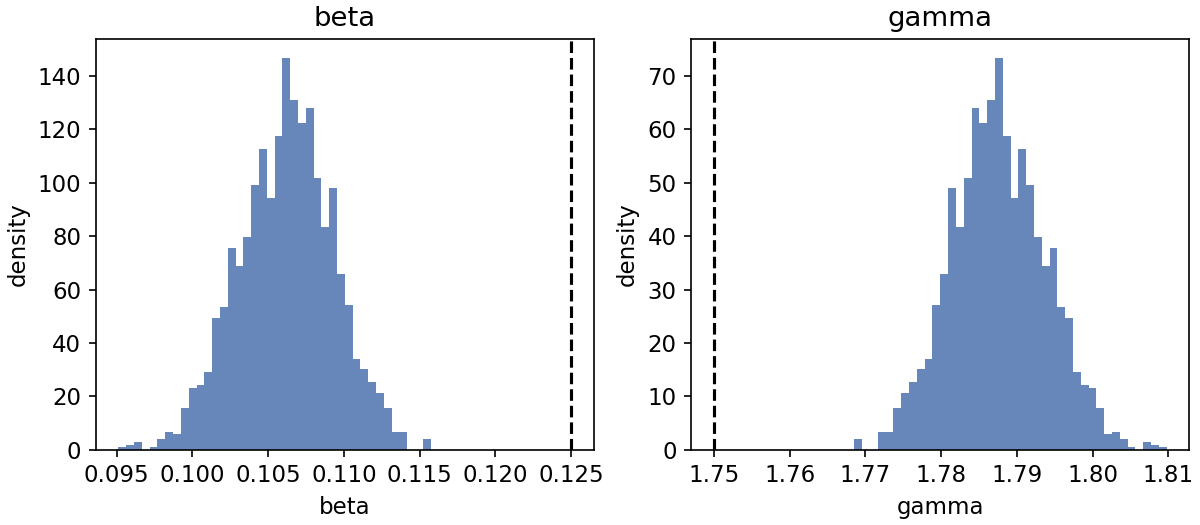

posterior_traces.png


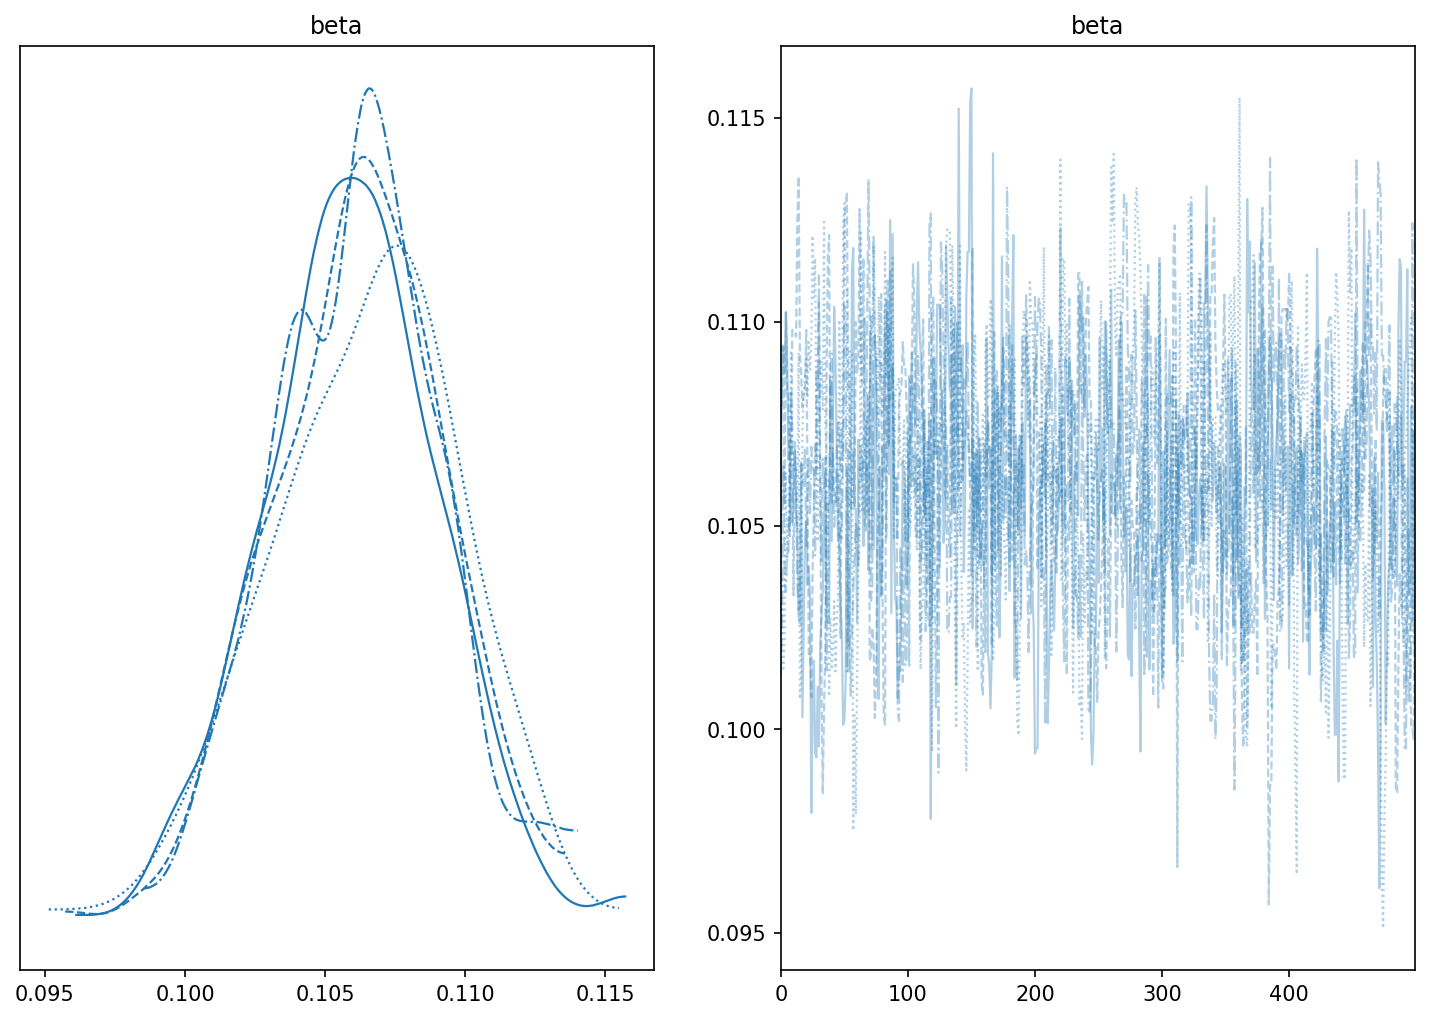

data_collapse.png


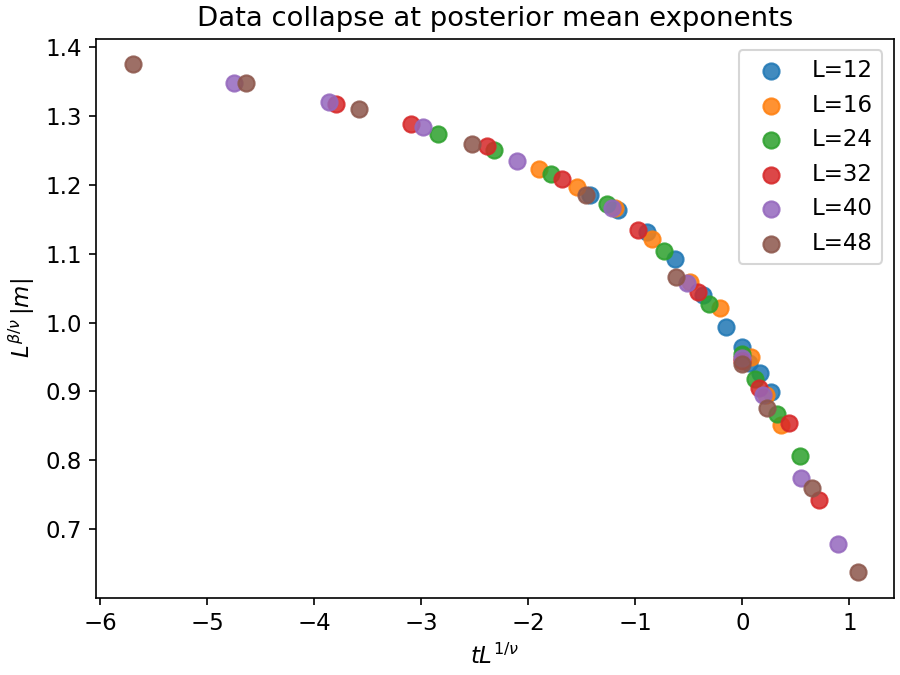

posterior_sample_collapses.png


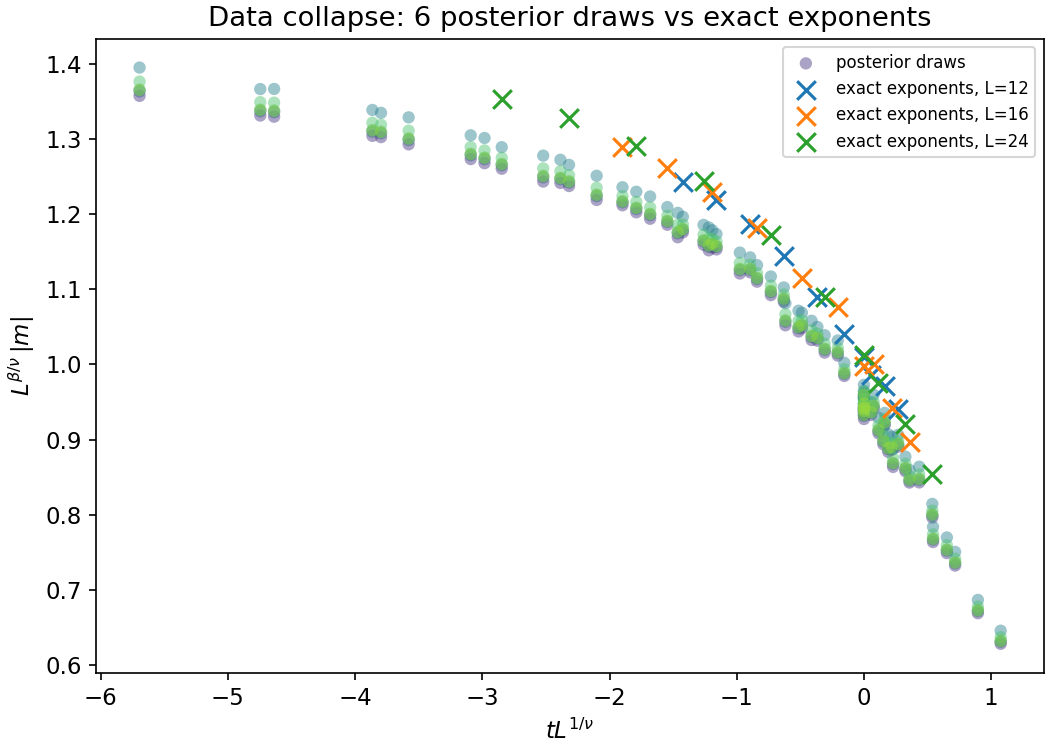

posterior_sample_scaling_curves.png


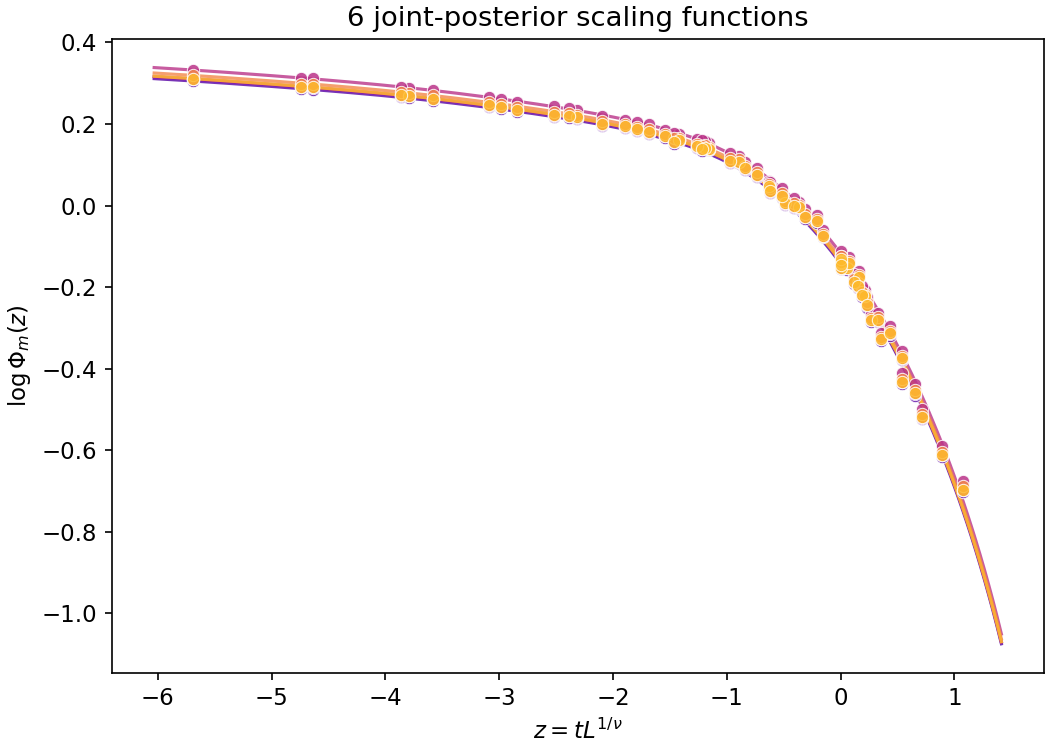

scaling_function_posterior.png


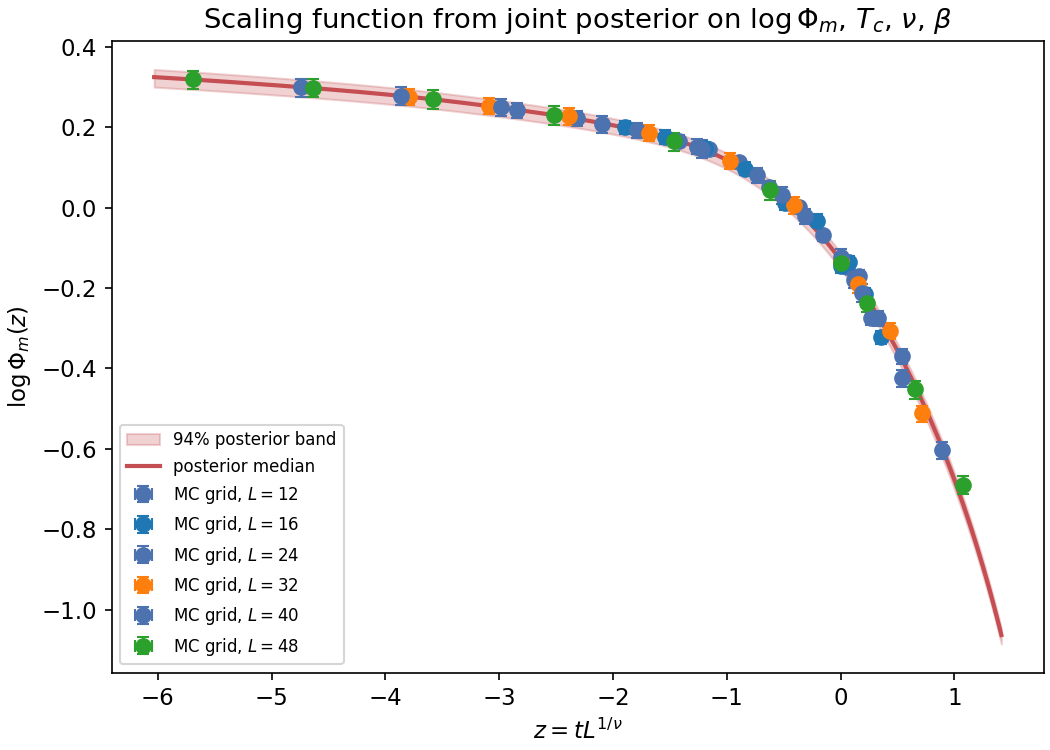

t_slice.png


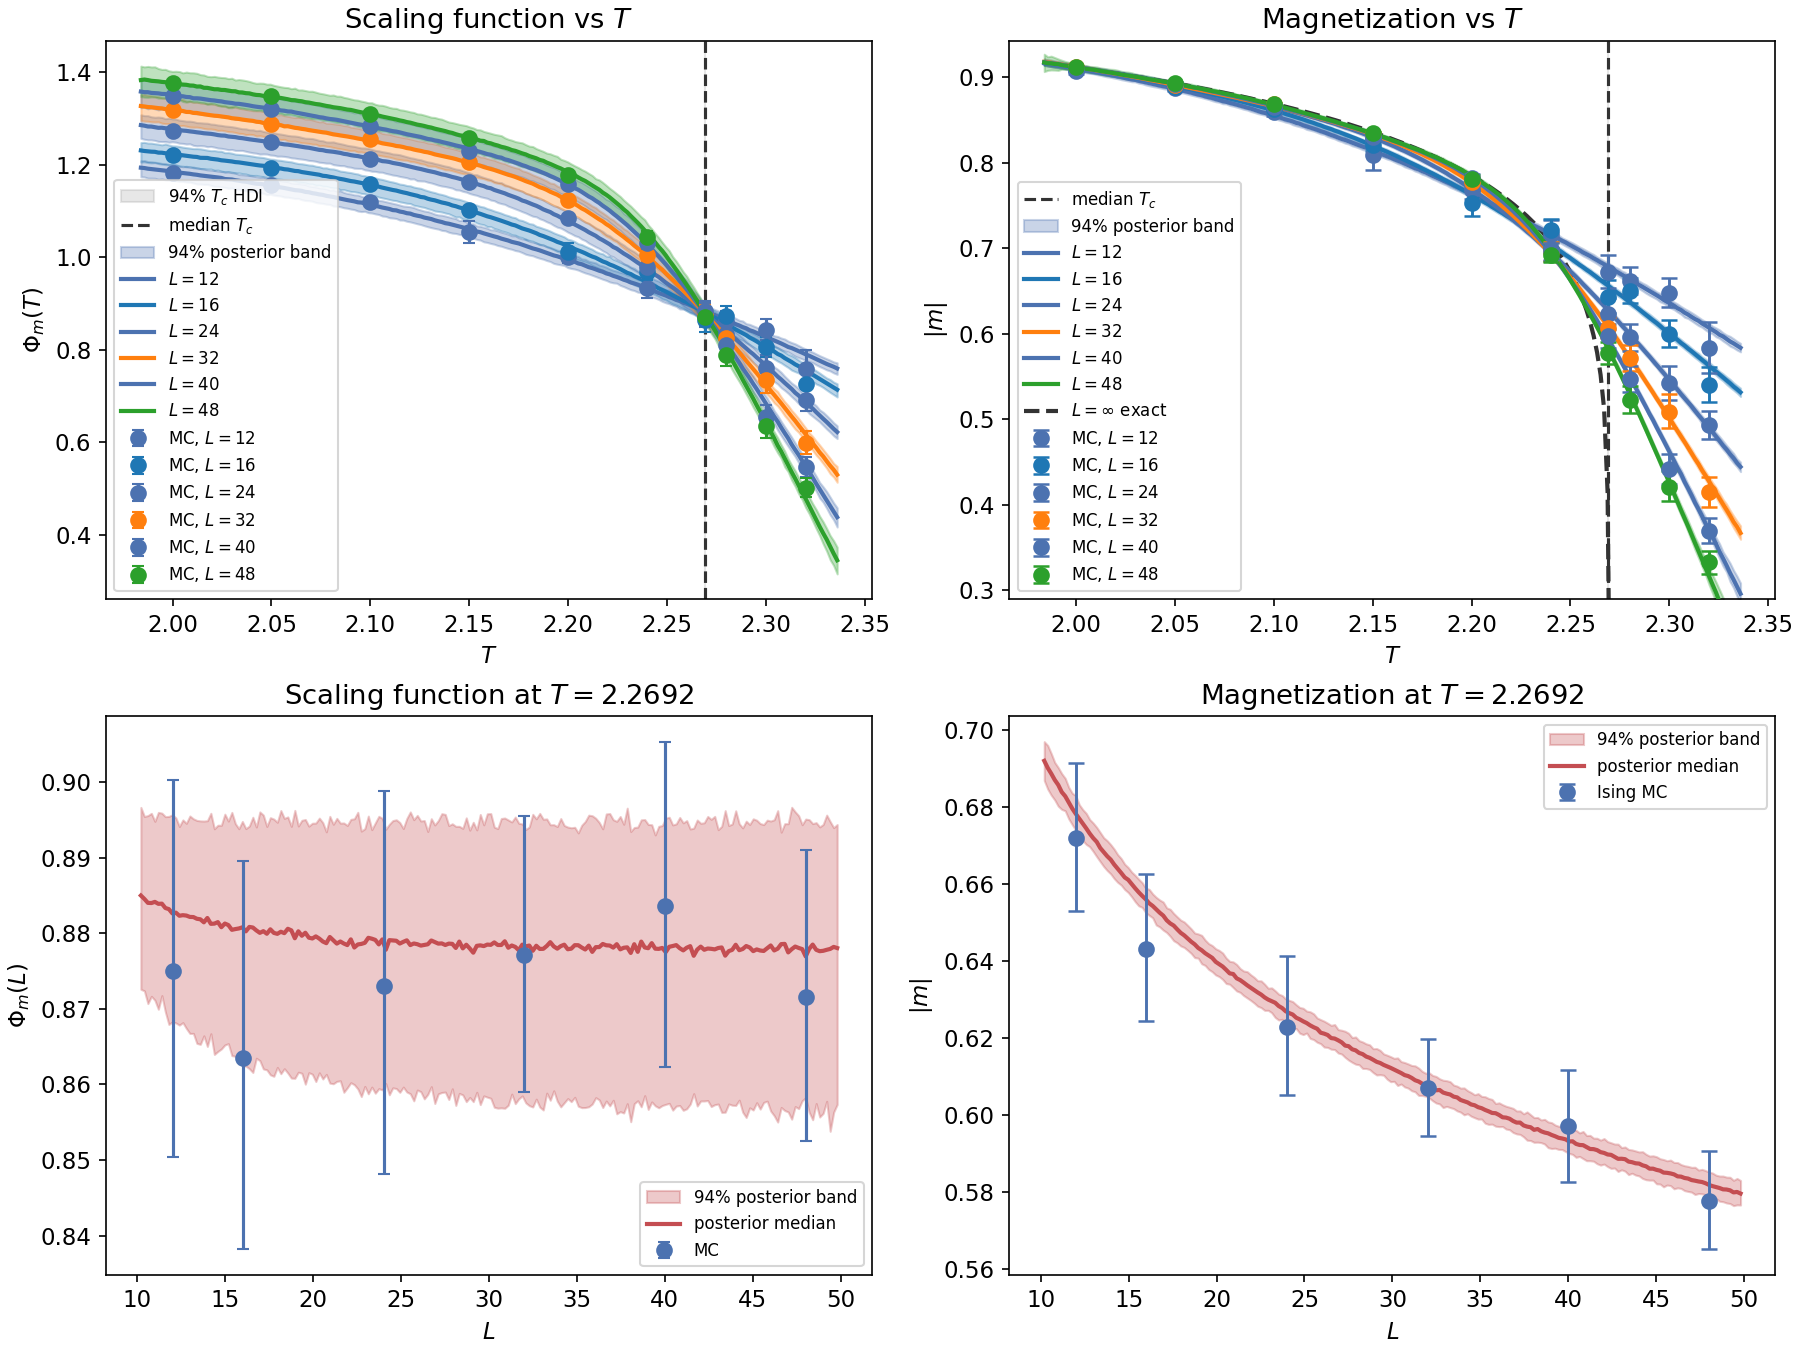

In [ ]:
if REDO_PLOT or not (plots_path / "posterior_exponents.png").exists():
    plot_paths = plot_posterior.plot_dataset(
        DATASET,
        model=MODEL,
        data=data_path,
        posterior=posterior_path,
        out=plots_path,
    )
else:
    plot_paths = sorted(plots_path.glob("*.png"))
    print(f"Skipping plot generation; showing existing files in {plots_path}")

for path in plot_paths:
    print(path.name)
    display(Image(filename=path))

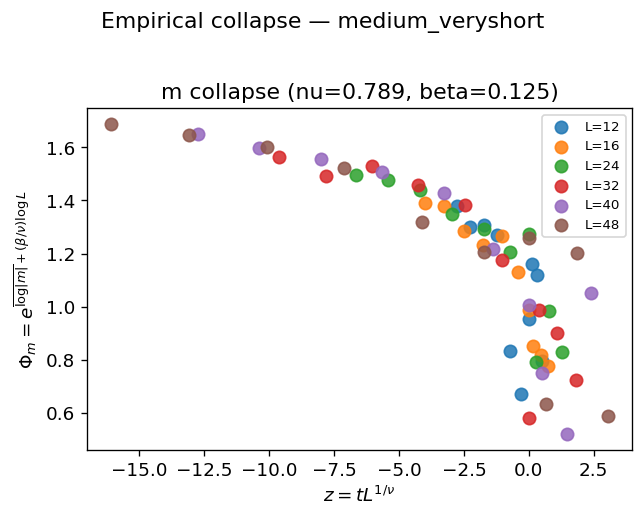

In [9]:
# Collapse at posterior mean exponents (updates after fit)
means = plot_posterior._posterior_means(idata)
df = pd.read_csv(data_path)
validate_observables_df(df)

empirical_collapse(
    df,
    T_c=means.get("T_c", TC_EXACT),
    nu=means.get("nu", NU_EXACT),
    beta=means.get("beta", BETA_EXACT),
    channels=COLLAPSE_CHANNELS,
)

In [10]:
# Active learning: rank extra-sweep candidates (dry run)
from ising.acquire import acquire_dataset

AL_EXTRA_SWEEPS = "10000,50000"
AL_TOP_K = 15
AL_MAX_IS_DRAWS = 300

if Path(posterior_path).exists():
    al_ranked = acquire_dataset(
        DATASET,
        dry_run=True,
        extra_sweeps_grid=tuple(int(x) for x in AL_EXTRA_SWEEPS.split(",")),
        top_k=AL_TOP_K,
        max_is_draws=AL_MAX_IS_DRAWS,
        data=data_path,
        posterior=posterior_path,
        infer_Tc=INFER_TC,
        infer_nu=INFER_NU,
        infer_beta=INFER_BETA,
        use_m=USE_M,
        use_m2=USE_M2,
        use_m4=USE_M4,
        use_binder=USE_BINDER,
        use_chi=USE_CHI,
        correction_m=CORRECTION_M,
        correction_m2=CORRECTION_M2,
        correction_m4=CORRECTION_M4,
        correction_binder=CORRECTION_BINDER,
        correction_chi=CORRECTION_CHI,
    )
    display(al_ranked.head(AL_TOP_K))
else:
    print(f"No posterior at {posterior_path}; run fit first.")


No posterior at /home/reuben/HMCLib/ising/posteriors/posterior_critical_fss.nc; run fit first.
